# **01 EDA — Instacart Market Basket Dataset**
## Proyecto Final: Insight Commerce - Sistema de Recomendación de Próxima Compra
  
**Dataset:** Instacart Market Basket Analysis (Kaggle 2017)  
**Objetivo:** Entender el comportamiento de compra, patrones de recompra y estructura del catálogo para diseñar un sistema de recomendación de próxima compra.

| Sección | Contenido |
|---|---|
| 0 | Configuración y carga |
| 1 | Estructura del dataset |
| 2 | Comportamiento de compra |
| 2.1 | Patrones temporales y tamaño de cesta |
| 3 | Análisis de recompra |
| 3.1 | Popularidad de productos y long tail |
| 4 | Productos y categorías |
| 4.1 | Perfiles de usuario y cohortes |
| 5 | Sparsity y cold start |
| 5.1 | Co-ocurrencia y preview de features              |
| 6   | Análisis orientado al modelo                      |
| 6.1 | Distribución de reordered (0 vs 1)               |
| 6.2 | Distribución del label real (prior vs train)     |
| 6.3 | Correlación entre features candidatas            |
| 6.4 | Cobertura de usuarios entre tablas               |
| 7   | Conclusiones y alertas                 |
| 8   | Próximos pasos sugeridos                         |


---

### Estructura del dataset

| Archivo | Descripción |
|---|---|
| `orders.csv` | Metadata de cada orden (usuario, hora, día, días desde última orden) |
| `order_products__prior.csv` | Productos de órdenes anteriores (historial completo) |
| `order_products__train.csv` | Productos de la última orden (conjunto de entrenamiento) |
| `products.csv` | Catálogo de productos con aisle y department |
| `aisles.csv` | Nombres de pasillos |
| `departments.csv` | Nombres de departamentos |

---

---
## 0. Configuración y Carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os
from itertools import combinations
from collections import Counter
from pathlib import Path
from dotenv import load_dotenv

warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#333333',
    'axes.grid': True, 'grid.color': '#eeeeee', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'font.size': 9,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'lines.linewidth': 1.8, 'patch.linewidth': 0.5,
    # ── Fix texto ──────────────────────────────────
    'text.color': '#222222',
    'axes.labelcolor': '#222222',
    'xtick.color': '#222222',
    'ytick.color': '#222222',
    'axes.titlecolor': '#222222',
    'legend.edgecolor': '#cccccc',
    'legend.facecolor': 'white',
})

# ── Paleta de colores global ────────────────────────────────────────────────────
P = ['#bded7e','#fe495f',"#f30521","#e5e377",'#fe9d97','#d8fd94']

def find_project_root(marker='.env'):
    """Sube directorios hasta encontrar el archivo marker."""
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'No se encontró {marker} en ningún directorio padre.')

PROJECT_ROOT = find_project_root()
load_dotenv(PROJECT_ROOT / '.env')

DATA_PATH   = str(PROJECT_ROOT / os.getenv('DATA_PATH', 'data/raw/'))
RANDOM_SEED = int(os.getenv('RANDOM_SEED', 42))

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'DATA_PATH    : {DATA_PATH}')
print(f'RANDOM_SEED  : {RANDOM_SEED}')

# ══════════════════════════════════════════════════════════════════════════════
# MVO — Muestra de Usuarios
# Ajustar N_USERS para trabajar con un subconjunto. None = dataset completo.
# Ejemplo: N_USERS = 10_000 para exploración rápida
#          N_USERS = None   para entrenamiento final
N_USERS     = 150_000    # <-- cambiar aquí
RANDOM_SEED = int(os.getenv('RANDOM_SEED', 42))
# ══════════════════════════════════════════════════════════════════════════════

PROJECT_ROOT : /Users/sofiaschanton/Desktop/Python3_Henry/Proyecto Final/insight-commerce-recsys
DATA_PATH    : /Users/sofiaschanton/Desktop/Python3_Henry/Proyecto Final/insight-commerce-recsys/data/raw
RANDOM_SEED  : 42


In [2]:
# ── Carga de los 6 archivos ────────────────────────────────────────────────────
orders       = pd.read_csv(f'{DATA_PATH}/orders.csv')
order_prior  = pd.read_csv(f'{DATA_PATH}/order_products__prior.csv')
order_train  = pd.read_csv(f'{DATA_PATH}/order_products__train.csv')
products     = pd.read_csv(f'{DATA_PATH}/products.csv')
aisles       = pd.read_csv(f'{DATA_PATH}/aisles.csv')
departments  = pd.read_csv(f'{DATA_PATH}/departments.csv')

# ── Aplicar MVO si N_USERS está definido ──────────────────────────────────────
all_users = orders['user_id'].unique()
if N_USERS is not None and N_USERS < len(all_users):
    rng          = np.random.default_rng(RANDOM_SEED)
    sampled_users = rng.choice(all_users, size=N_USERS, replace=False)
    orders        = orders[orders['user_id'].isin(sampled_users)].copy()
    sampled_orders = orders['order_id'].unique()
    order_prior   = order_prior[order_prior['order_id'].isin(sampled_orders)].copy()
    order_train   = order_train[order_train['order_id'].isin(sampled_orders)].copy()
    MVO_ACTIVO = True
else:
    MVO_ACTIVO = False

# ── Dataset enriquecido (join central) ────────────────────────────────────────
products_full = products.merge(aisles, on='aisle_id').merge(departments, on='department_id')
prior_full = (
    order_prior
    .merge(orders[['order_id','user_id','order_number','order_dow',
                   'order_hour_of_day','days_since_prior_order']], on='order_id')
    .merge(products_full[['product_id','product_name','aisle','department']], on='product_id')
)

modo = f'MVO activo — {N_USERS:,} usuarios (seed={RANDOM_SEED})' if MVO_ACTIVO else 'Dataset completo'
print(f'Modo: {modo}')
print()
for name, df in [('orders',orders),('order_prior',order_prior),('order_train',order_train),
                 ('products',products),('aisles',aisles),('departments',departments)]:
    print(f'  {name:28s}: {df.shape[0]:>10,.0f} filas  x  {df.shape[1]} cols')
print(f'  {"prior_full (join central)":28s}: {prior_full.shape[0]:>10,.0f} filas  x  {prior_full.shape[1]} cols')

Modo: MVO activo — 150,000 usuarios (seed=42)

  orders                      :  2,484,196 filas  x  7 cols
  order_prior                 : 23,534,276 filas  x  4 cols
  order_train                 :  1,008,890 filas  x  4 cols
  products                    :     49,688 filas  x  4 cols
  aisles                      :        134 filas  x  2 cols
  departments                 :         21 filas  x  2 cols
  prior_full (join central)   : 23,534,276 filas  x  12 cols


In [3]:
# ── Variables base pre-calculadas (reutilizadas en múltiples secciones) ────────
orders_per_user = orders.groupby('user_id')['order_number'].max()
cart_size       = prior_full.groupby('order_id')['product_id'].count()
days_since      = orders['days_since_prior_order'].dropna()
global_reorder  = prior_full['reordered'].mean()
orders_hour     = orders['order_hour_of_day'].value_counts().sort_index()
dow_labels      = {0:'Domingo',1:'Lunes',2:'Martes',3:'Miercoles',4:'Jueves',5:'Viernes',6:'Sabado'}
orders_dow      = orders['order_dow'].map(dow_labels).value_counts().reindex(dow_labels.values())

print('Variables base pre-calculadas:')
print(f'  orders_per_user  — mediana : {orders_per_user.median():.0f}  |  media : {orders_per_user.mean():.1f}')
print(f'  cart_size        — mediana : {cart_size.median():.0f}  |  media : {cart_size.mean():.1f}')
print(f'  days_since       — mediana : {days_since.median():.0f}  |  media : {days_since.mean():.1f}')
print(f'  global_reorder   — tasa    : {global_reorder:.4f}  ({global_reorder:.2%})')
print(f'  hora pico        — hora    : {orders_hour.idxmax()}:00h')
print(f'  dia pico         — dia     : {orders_dow.idxmax()}')

Variables base pre-calculadas:
  orders_per_user  — mediana : 10  |  media : 16.6
  cart_size        — mediana : 8  |  media : 10.1
  days_since       — mediana : 7  |  media : 11.1
  global_reorder   — tasa    : 0.5894  (58.94%)
  hora pico        — hora    : 10:00h
  dia pico         — dia     : Domingo


In [4]:
print(f'Usuarios         : {orders["user_id"].nunique():,}')
print(f'Órdenes prior    : {orders[orders["eval_set"]=="prior"]["order_id"].nunique():,}')
print(f'Filas prior_full : {len(prior_full):,}')
print(f'Filas train      : {len(order_train):,}')
print(f'RAM usada aprox  : {prior_full.memory_usage(deep=True).sum() / 1e9:.2f} GB')

Usuarios         : 150,000
Órdenes prior    : 2,334,196
Filas prior_full : 23,534,276
Filas train      : 1,008,890
RAM usada aprox  : 6.84 GB


### **Resultados — Sección 0**

- Los 6 archivos se cargan correctamente sin errores de parsing.
- **MVO**: si `N_USERS` es distinto de `None`, todo el pipeline (orders, order_prior, order_train, prior_full) se filtra de forma consistente por los usuarios muestreados. Cambiar solo esa variable y re-ejecutar es suficiente.
- Las variables base (`orders_per_user`, `cart_size`, `days_since`, `global_reorder`, `orders_hour`, `orders_dow`) se pre-calculan aquí y se reutilizan en todas las secciones siguientes sin recomputar.
- `prior_full` (~32M filas en modo completo) integra orden, usuario, producto, aisle y departamento en una sola tabla.

---
## 1. Estructura del Dataset
Antes de realizar cualquier análisis es necesario examinar la estructura del dataset para comprender sus características básicas. En esta etapa se revisa el número de registros por tabla, los tipos de datos de cada variable y la presencia de valores faltantes.

Esta exploración inicial permite evaluar la calidad de los datos y establecer criterios adecuados para su limpieza, transformación y posterior análisis.

In [5]:
def quality_report(df, name):
    r = pd.DataFrame({'dtype':df.dtypes,'nulls':df.isnull().sum(),
                      'null_%':(df.isnull().mean()*100).round(2),'unique':df.nunique(),'sample':df.iloc[0]})
    print(f'\n=== {name} ===')
    display(r)

for name, df in [('orders',orders),('order_prior',order_prior),('order_train',order_train),
                 ('products',products),('aisles',aisles),('departments',departments)]:
    quality_report(df, name)


=== orders ===


,dtype,nulls,null_%,unique,sample
order_id,int64,0,0.00,2484196,2539329
user_id,int64,0,0.00,150000,1
eval_set,object,0,0.00,3,prior
order_number,int64,0,0.00,100,1
order_dow,int64,0,0.00,7,2
order_hour_of_day,int64,0,0.00,24,8
days_since_prior_order,float64,150000,6.04,31,NaN



=== order_prior ===


,dtype,nulls,null_%,unique,sample
order_id,int64,0,0.0,2334196,4
product_id,int64,0,0.0,49559,46842
add_to_cart_order,int64,0,0.0,145,1
reordered,int64,0,0.0,2,0



=== order_train ===


...

,dtype,nulls,null_%,unique,sample
product_id,int64,0,0.0,49688,1
product_name,object,0,0.0,49688,Chocolate Sandwich Cookies
aisle_id,int64,0,0.0,134,61
department_id,int64,0,0.0,21,19



=== aisles ===


,dtype,nulls,null_%,unique,sample
aisle_id,int64,0,0.0,134,1
aisle,object,0,0.0,134,prepared soups salads



=== departments ===


,dtype,nulls,null_%,unique,sample
department_id,int64,0,0.0,21,1
department,object,0,0.0,21,frozen


── Resumen general ──────────────────────────────
  Usuarios únicos       :    150,000
  Órdenes únicas        :  2,484,196
  Productos únicos      :     49,688
  Departamentos         :         21
  Pasillos              :        134
  Registros prior       : 23,534,276
  Registros train       :  1,008,890
─────────────────────────────────────────────────

Filas con days_since_prior_order=NaN : 150,000
Coinciden (esperado True)            : True

Distribucion eval_set:
          ordenes
eval_set         
prior     2334196
train       95551
test        54449


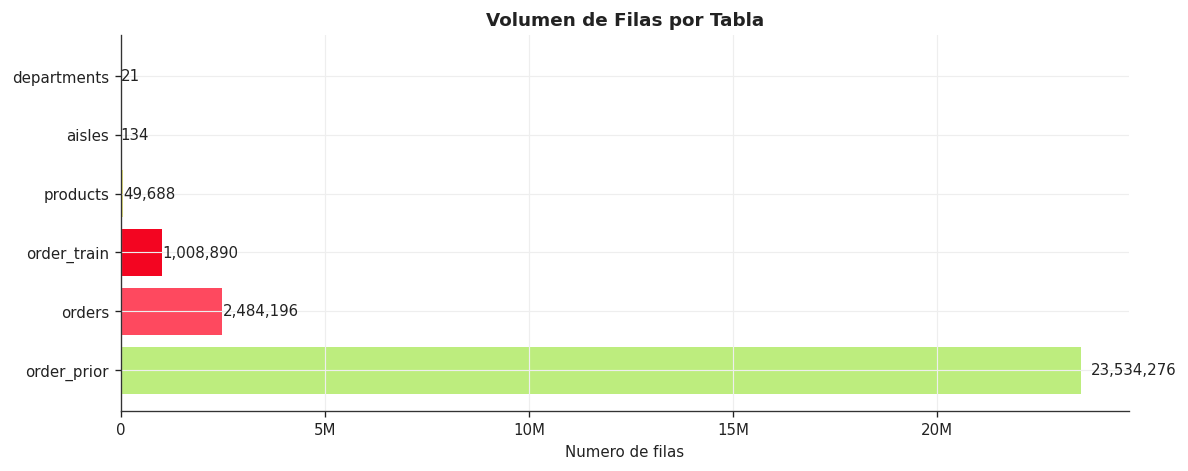

In [6]:
first_orders = orders[orders['days_since_prior_order'].isnull()]
n_users      = orders['user_id'].nunique()
n_orders     = orders['order_id'].nunique()
n_products   = products['product_id'].nunique()
n_depts      = departments['department_id'].nunique()
n_aisles     = aisles['aisle_id'].nunique()
n_prior      = len(order_prior)
n_train      = len(order_train)

print('── Resumen general ──────────────────────────────')
print(f'  Usuarios únicos       : {n_users:>10,}')
print(f'  Órdenes únicas        : {n_orders:>10,}')
print(f'  Productos únicos      : {n_products:>10,}')
print(f'  Departamentos         : {n_depts:>10,}')
print(f'  Pasillos              : {n_aisles:>10,}')
print(f'  Registros prior       : {n_prior:>10,}')
print(f'  Registros train       : {n_train:>10,}')
print('─────────────────────────────────────────────────')
print(f'\nFilas con days_since_prior_order=NaN : {len(first_orders):,}')
print(f'Coinciden (esperado True)            : {len(first_orders) == n_users}')
print('\nDistribucion eval_set:')
print(orders['eval_set'].value_counts().to_frame('ordenes'))

table_sizes = {'order_prior':len(order_prior),'orders':len(orders),'order_train':len(order_train),
               'products':len(products),'aisles':len(aisles),'departments':len(departments)}
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(list(table_sizes.keys()), list(table_sizes.values()), color=P[:6])
ax.set_title('Volumen de Filas por Tabla', fontweight='bold')
ax.set_xlabel('Numero de filas')
for bar, val in zip(bars, table_sizes.values()):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.0f}M' if x>=1e6 else f'{int(x):,}'))
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/resumen_general.png', dpi=150, bbox_inches='tight')
plt.show()

### **Resultados — Sección 1**

El dataset contiene 206,209 usuarios con 3,421,083 órdenes y 32,434,489 registros en el historial de compras (order_products_prior). El catálogo de productos es completo con 49,688 productos distribuidos en 21 departamentos y 134 pasillos.

Si `N_USERS`=50,000 la muestra contiene 831.128 órdenes y 7.927.707 registros en el historial de compras (order_products_prior)

- #### *Observación sobre nulos*
`days_since_prior_order` tiene exactamente un nulo por usuario — su primera orden, que por definición no tiene orden anterior. Es un **nulo estructural esperado**, no un problema de calidad. Se lo trata con un flag `is_first_order`.

- #### *Columna `eval_set`*
Clasifica cada orden en `prior` (historial), `train` (target del modelo) o `test` (evaluación Kaggle sin ground truth). Esta columna es metadata de la competencia — no es una variable de negocio y no se usará como feature.

- #### *`aisles`, `departments`*
Los catálogos (`aisles`, `departments`) son pequeños y estables — ideales para encoding directo.

- #### *Duplicados*
No hay duplicados ni inconsistencias de claves primarias en ninguna tabla.

---
## 2. Comportamiento de Compra
Comprender el comportamiento de compra de los usuarios es el punto de partida para construir un sistema de recomendación con impacto real. La frecuencia con la que un usuario ordena, la cantidad de productos que lleva por orden y los momentos en que elige comprar no son simplemente estadísticas descriptivas — son señales que determinan cuándo y cómo el sistema puede influir en la decisión de compra.

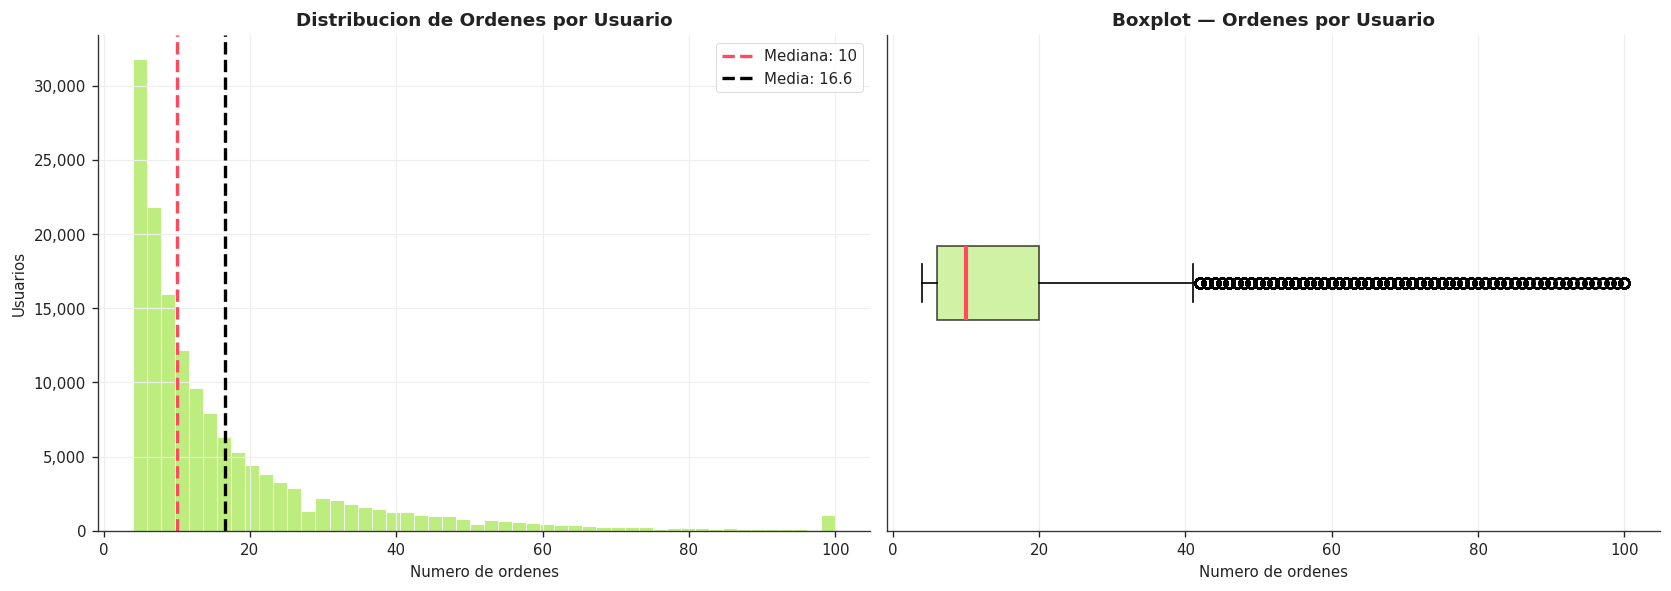

                        count       mean        std  min  25%   50%   75%    max
Ordenes por usuario  150000.0  16.561307  16.633842  4.0  6.0  10.0  20.0  100.0


In [7]:
# orders_per_user, cart_size, days_since, global_reorder pre-calculados en sección 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(orders_per_user, bins=50, color=P[0], edgecolor='white', linewidth=0.5)
axes[0].axvline(orders_per_user.median(), color=P[1], lw=2, linestyle='--', label=f'Mediana: {orders_per_user.median():.0f}')
axes[0].axvline(orders_per_user.mean(), color='black', lw=2, linestyle='--', label=f'Media: {orders_per_user.mean():.1f}')
axes[0].set_title('Distribucion de Ordenes por Usuario', fontweight='bold')
axes[0].set_xlabel('Numero de ordenes'); axes[0].set_ylabel('Usuarios'); axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

axes[1].boxplot(orders_per_user, vert=False, patch_artist=True,
                boxprops=dict(facecolor=P[0],alpha=0.7), medianprops=dict(color=P[1],linewidth=2.5))
axes[1].set_title('Boxplot — Ordenes por Usuario', fontweight='bold')
axes[1].set_xlabel('Numero de ordenes'); axes[1].set_yticks([])
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/distribucion_ordenes_carrito.png', dpi=150, bbox_inches='tight')
plt.show()
print(orders_per_user.describe().to_frame('Ordenes por usuario').T.to_string())

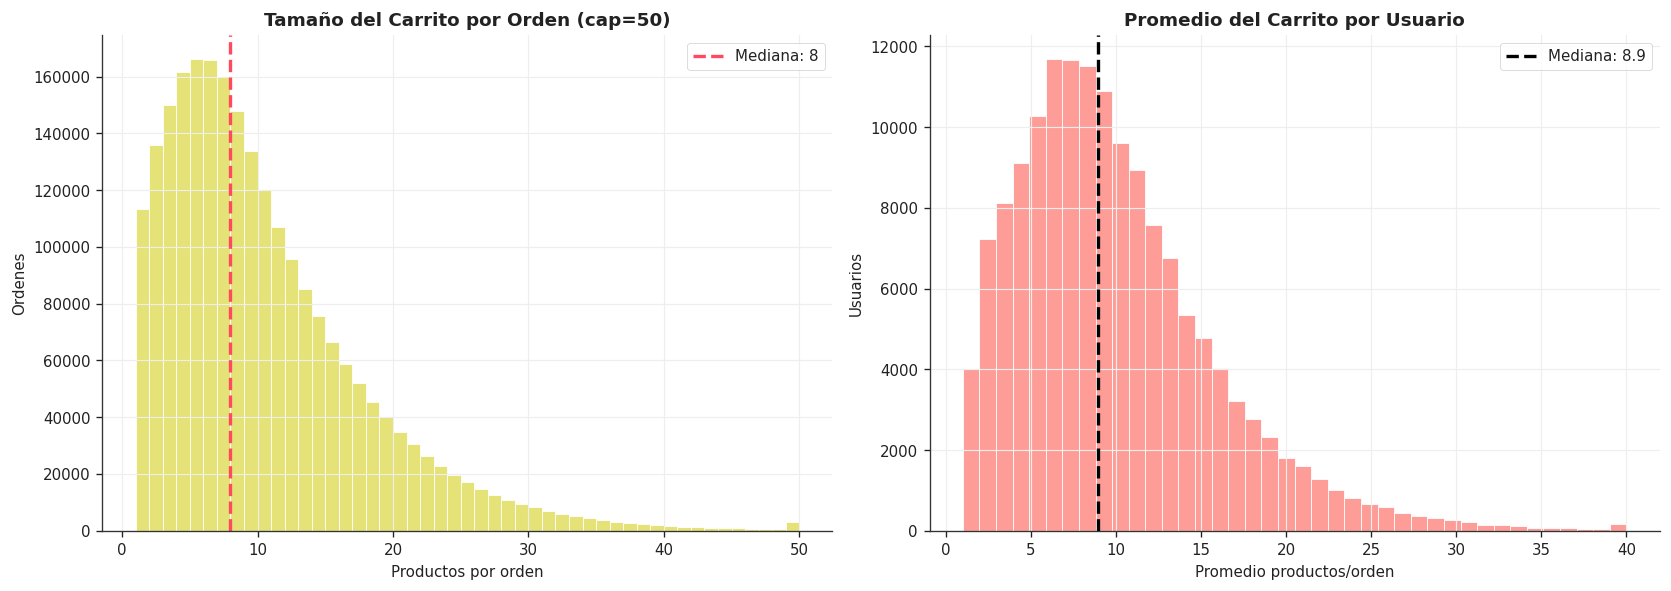

Tamaño del Carrito — Media: 10.1 | Mediana: 8 | Max: 145


In [8]:
avg_cart  = prior_full.groupby(['user_id','order_id'])['product_id'].count().groupby('user_id').mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cart_size.clip(upper=50), bins=49, color=P[3], edgecolor='white', linewidth=0.5)
axes[0].axvline(cart_size.median(), color=P[1], lw=2, linestyle='--', label=f'Mediana: {cart_size.median():.0f}')
axes[0].set_title('Tamaño del Carrito por Orden (cap=50)', fontweight='bold')
axes[0].set_xlabel('Productos por orden'); axes[0].set_ylabel('Ordenes'); axes[0].legend()

axes[1].hist(avg_cart.clip(upper=40), bins=40, color=P[4], edgecolor='white', linewidth=0.5)
axes[1].axvline(avg_cart.median(), color='black', lw=2, linestyle='--', label=f'Mediana: {avg_cart.median():.1f}')
axes[1].set_title('Promedio del Carrito por Usuario', fontweight='bold')
axes[1].set_xlabel('Promedio productos/orden'); axes[1].set_ylabel('Usuarios'); axes[1].legend()
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/tamano_carrito_avg_basket.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Tamaño del Carrito — Media: {cart_size.mean():.1f} | Mediana: {cart_size.median():.0f} | Max: {cart_size.max()}')

###  **Resultados — Sección 2**

- #### *Distribución de órdenes por usuario*
La distribución tiene una forma de cola larga hacia la derecha, con la
mayoría de los usuarios concentrados entre 4 y 20 órdenes. La mediana
es de 10 órdenes y el promedio de 16.6, lo que indica que un grupo de
usuarios muy activos (con hasta 100 órdenes) eleva el promedio.

**Implicancia para el modelo:** usuarios con pocas órdenes tienen menos
historial disponible para construir features confiables — esto es el
problema de cold start que deberá manejar DS-2 en el feature engineering.

- #### *Distribución del tamaño del carrito*
El carrito promedio tiene 10.1 productos y la mediana es 8, con una
distribución que también tiene cola derecha. La gran mayoría de las
órdenes tienen entre 1 y 20 productos.

**Implicancia para el modelo:** el tamaño promedio del carrito es el
baseline de negocio contra el que se medirá el Basket Size Uplift.
Si el modelo logra que usuarios compren más productos por orden,
ese delta es el valor directo que genera el sistema de recomendación.

---
## 2.1 Patrones Temporales y Tamaño de Cesta

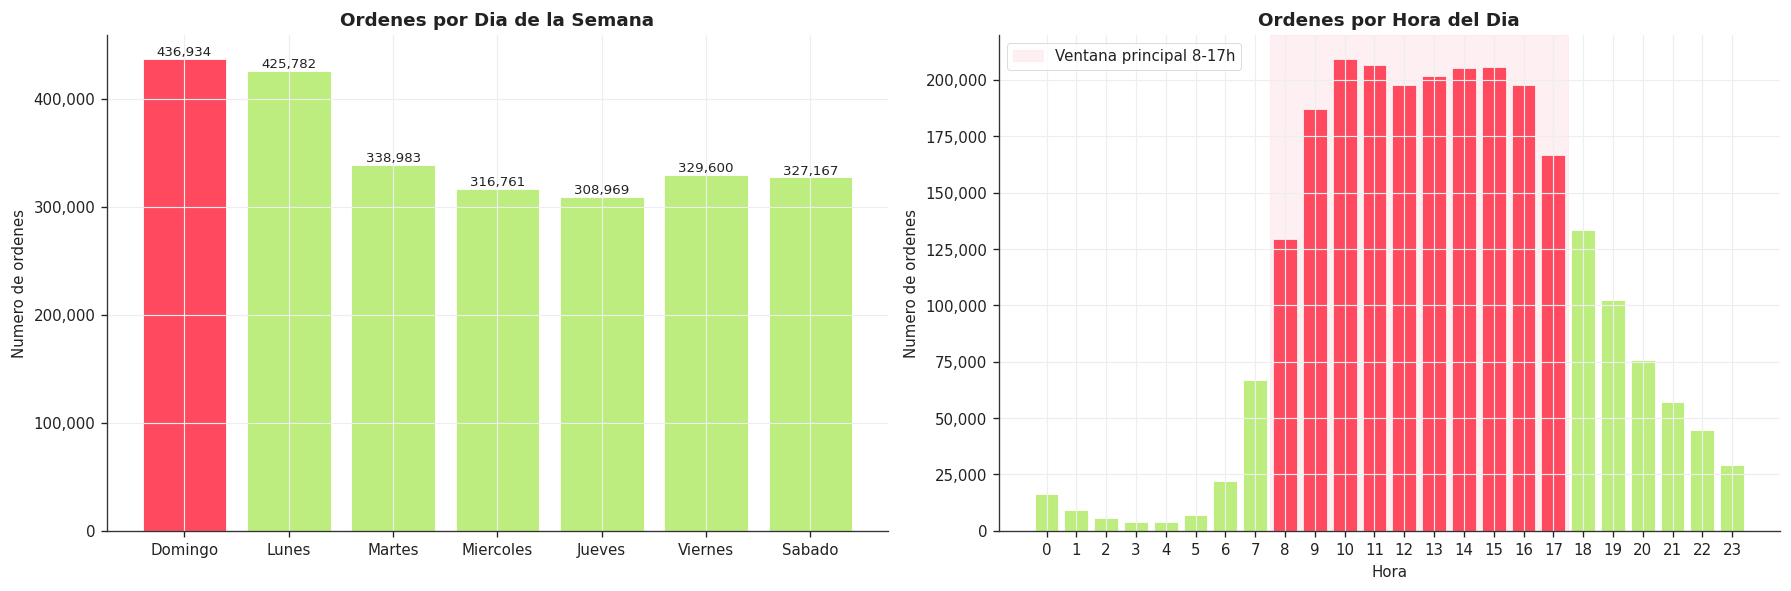

In [9]:
# dow_labels, orders_dow, orders_hour pre-calculados en sección 0

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors_dow = [P[1] if v==orders_dow.max() else P[0] for v in orders_dow.values]
bars = axes[0].bar(orders_dow.index, orders_dow.values, color=colors_dow, edgecolor='white')
axes[0].set_title('Ordenes por Dia de la Semana', fontweight='bold')
axes[0].set_ylabel('Numero de ordenes')
for bar, val in zip(bars, orders_dow.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+300, f'{val:,}', ha='center', va='bottom', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

colors_h = [P[1] if (8<=h<=17) else P[0] for h in orders_hour.index]
axes[1].bar(orders_hour.index, orders_hour.values, color=colors_h, edgecolor='white')
axes[1].axvspan(7.5,17.5,alpha=0.08,color=P[1],label='Ventana principal 8-17h')
axes[1].set_title('Ordenes por Hora del Dia', fontweight='bold')
axes[1].set_xlabel('Hora'); axes[1].set_ylabel('Numero de ordenes')
axes[1].set_xticks(range(0,24)); axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/ordenes_dia_hora.png', dpi=150, bbox_inches='tight')
plt.show()

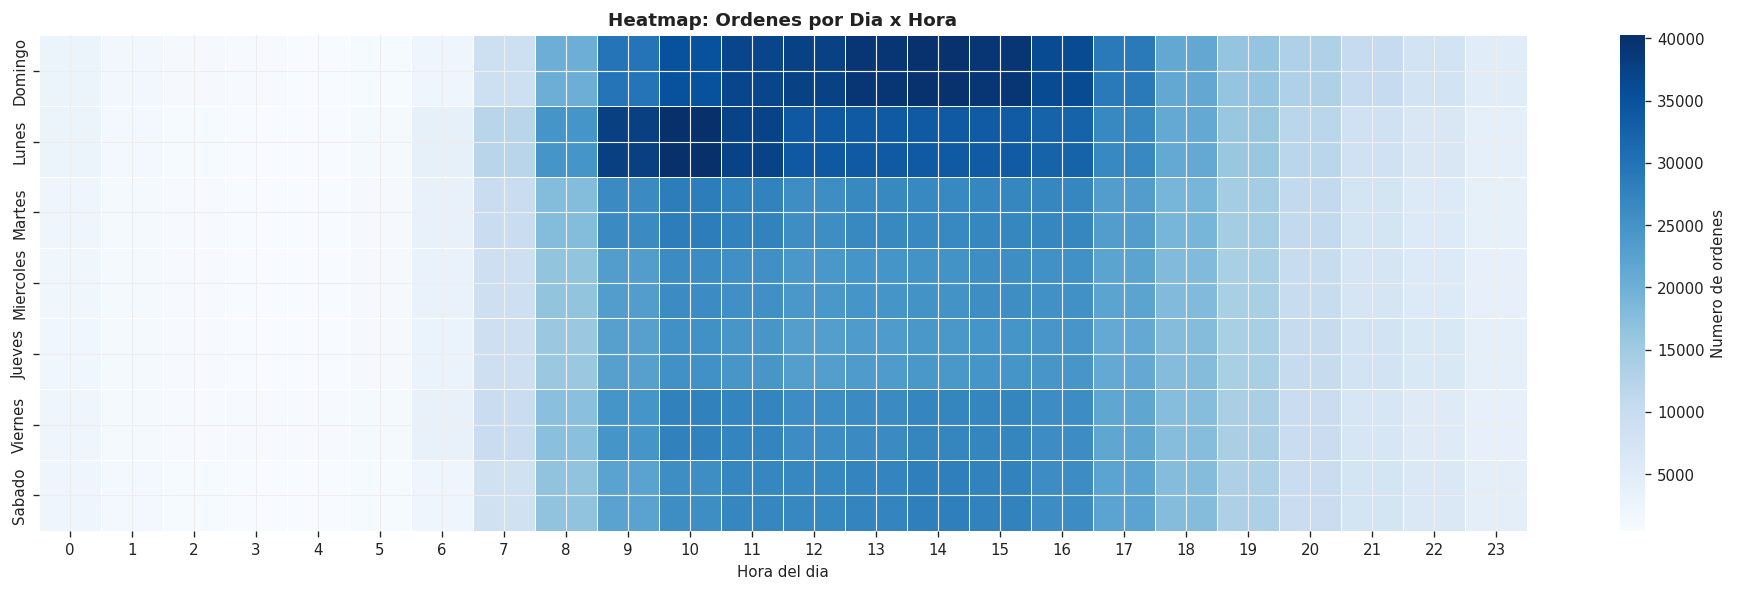

In [10]:
hm = orders.groupby(['order_dow','order_hour_of_day']).size().unstack(fill_value=0)
hm.index = [dow_labels[i] for i in hm.index]
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(hm, cmap='Blues', ax=ax, linewidths=0.3, cbar_kws={'label':'Numero de ordenes'})
ax.set_title('Heatmap: Ordenes por Dia x Hora', fontweight='bold')
ax.set_xlabel('Hora del dia'); ax.set_ylabel('')
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/heatmap_dia_hora.png', dpi=150, bbox_inches='tight')
plt.show()

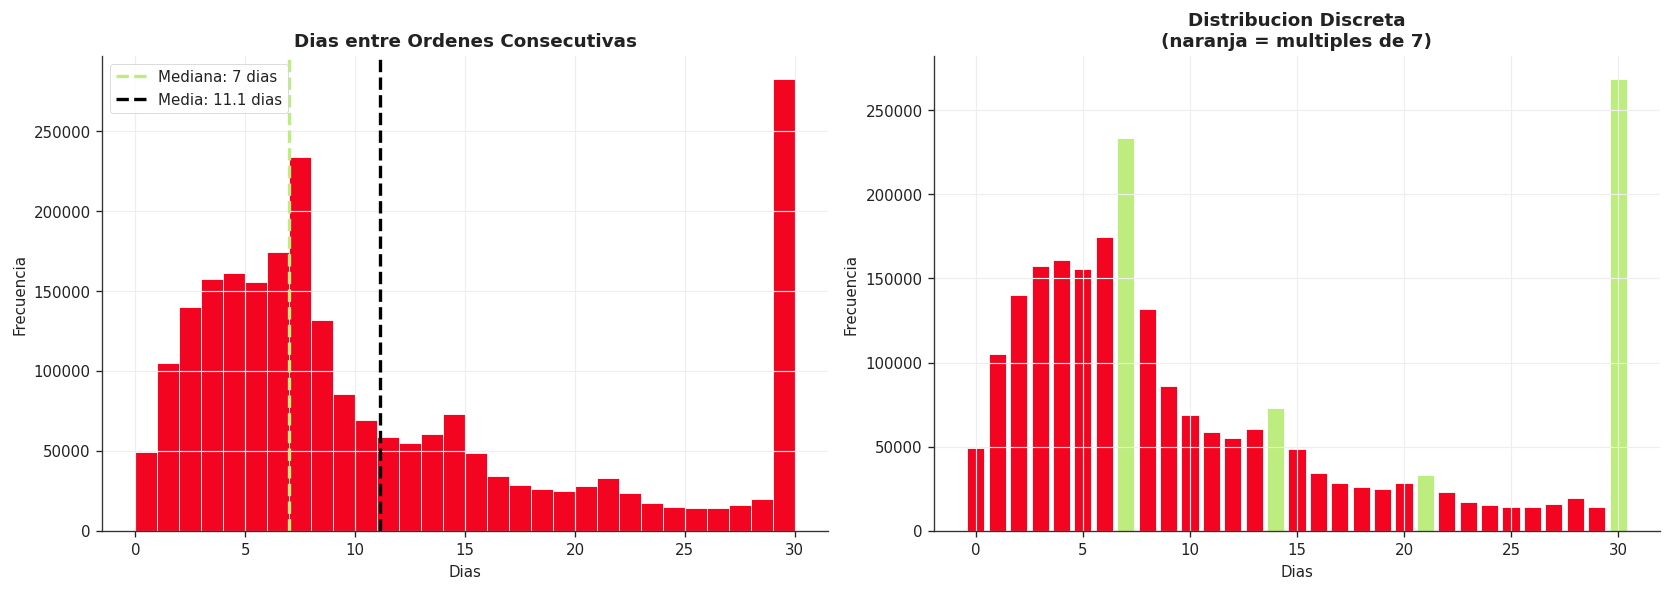

In [11]:
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(days_since, bins=30, color=P[2], edgecolor='white', linewidth=0.5)
axes[0].axvline(days_since.median(),color=P[0],lw=2,linestyle='--',label=f'Mediana: {days_since.median():.0f} dias')
axes[0].axvline(days_since.mean(),  color='black',lw=2,linestyle='--',label=f'Media: {days_since.mean():.1f} dias')
axes[0].set_title('Dias entre Ordenes Consecutivas', fontweight='bold')
axes[0].set_xlabel('Dias'); axes[0].set_ylabel('Frecuencia'); axes[0].legend()

disc = days_since.value_counts().sort_index()
colors_d = [P[0] if x in [7,14,21,30] else P[2] for x in disc.index]
axes[1].bar(disc.index, disc.values, color=colors_d, edgecolor='white')
axes[1].set_title('Distribucion Discreta\n(naranja = multiples de 7)', fontweight='bold')
axes[1].set_xlabel('Dias'); axes[1].set_ylabel('Frecuencia')
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/dias_entre_ordenes.png', dpi=150, bbox_inches='tight')
plt.show()

###  **Resultados — Sección 2.1**

- #### *Temporalidad de las compras*
Domingo y lunes concentran el mayor volumen de órdenes, con una caída
progresiva hacia mediados de semana. En cuanto a la hora del día, el
horario pico es entre las 08 y las 17 hs, con volumen casi nulo entre
las 0 y las 6 hs. El heatmap confirma que **Domingo mañana** es el slot de mayor densidad.

**Implicancia para el modelo:** `order_dow` y `order_hour_of_day` son
features temporales con señal real — el día y la hora en que un usuario
suele comprar es información útil para predecir su próxima compra.

- #### *Recencia entre compras*
El promedio de días entre órdenes revela el ciclo de recompra típico del usuario y constituye una variable clave para el modelo. Si un usuario suele comprar cada 7 días y su última compra fue hace 6, es probable que esté cerca de realizar su próxima orden. 
Los picos marcados en 7, 14, 21 y 30 días entre pedidos confirman un comportamiento cíclico semanal y mensual, lo que convierte a `days_since_prior_order` en una feature temporal crítica para el análisis y la predicción.

---
## 3. Análisis de Recompra

La recompra es el núcleo del problema. Un sistema de next-basket recommendation busca predecir qué productos volverá a comprar un usuario en su próxima orden. Analizar la tasa de recompra —tanto a nivel global como por producto y por usuario— permite evaluar qué tan predecible es el comportamiento de compra y qué tan fuerte es la señal disponible para que el modelo aprenda.

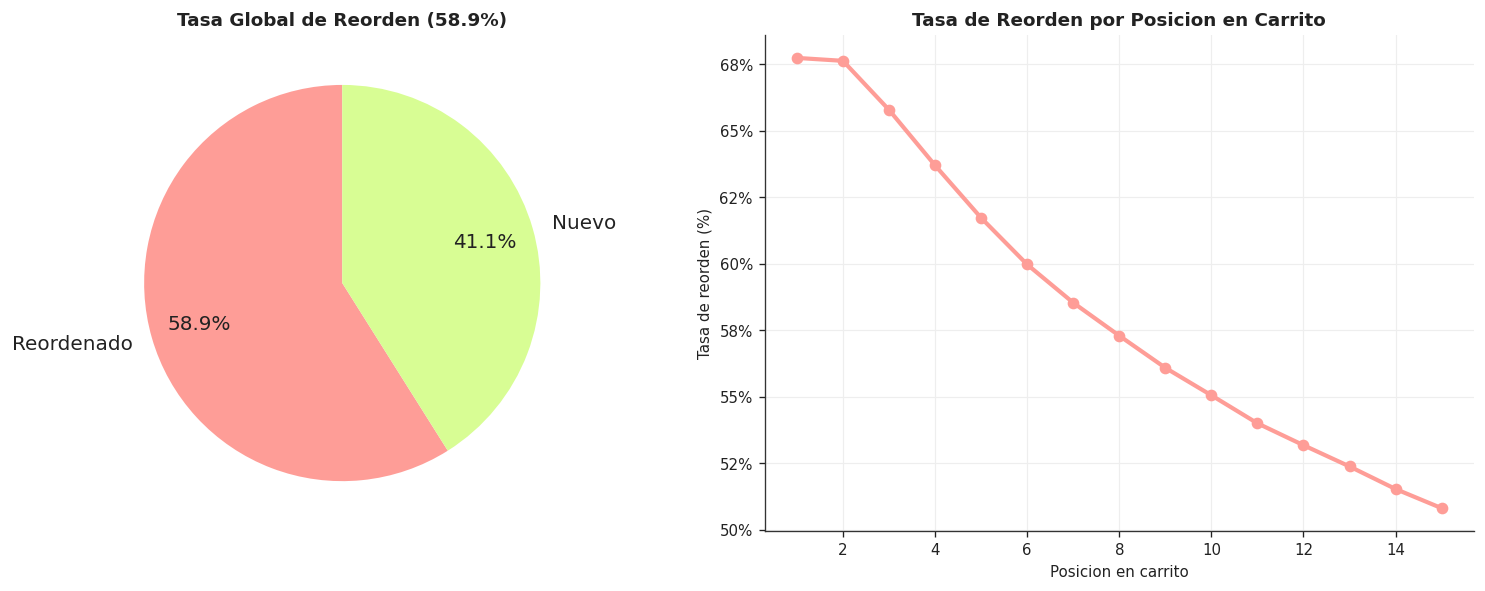

In [12]:
# global_reorder pre-calculado en sección 0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie([global_reorder,1-global_reorder], labels=['Reordenado','Nuevo'],
            colors=[P[4],P[5]], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':12}, pctdistance=0.75)
axes[0].set_title(f'Tasa Global de Reorden ({global_reorder:.1%})', fontweight='bold')

reorder_pos = (prior_full[prior_full['add_to_cart_order']<=15]
               .groupby('add_to_cart_order')['reordered'].mean())
axes[1].plot(reorder_pos.index, reorder_pos.values*100, marker='o', color=P[4], lw=2.5, markersize=6)
axes[1].set_title('Tasa de Reorden por Posicion en Carrito', fontweight='bold')
axes[1].set_xlabel('Posicion en carrito'); axes[1].set_ylabel('Tasa de reorden (%)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/tasa_reorden_global.png', dpi=150, bbox_inches='tight')
plt.show()

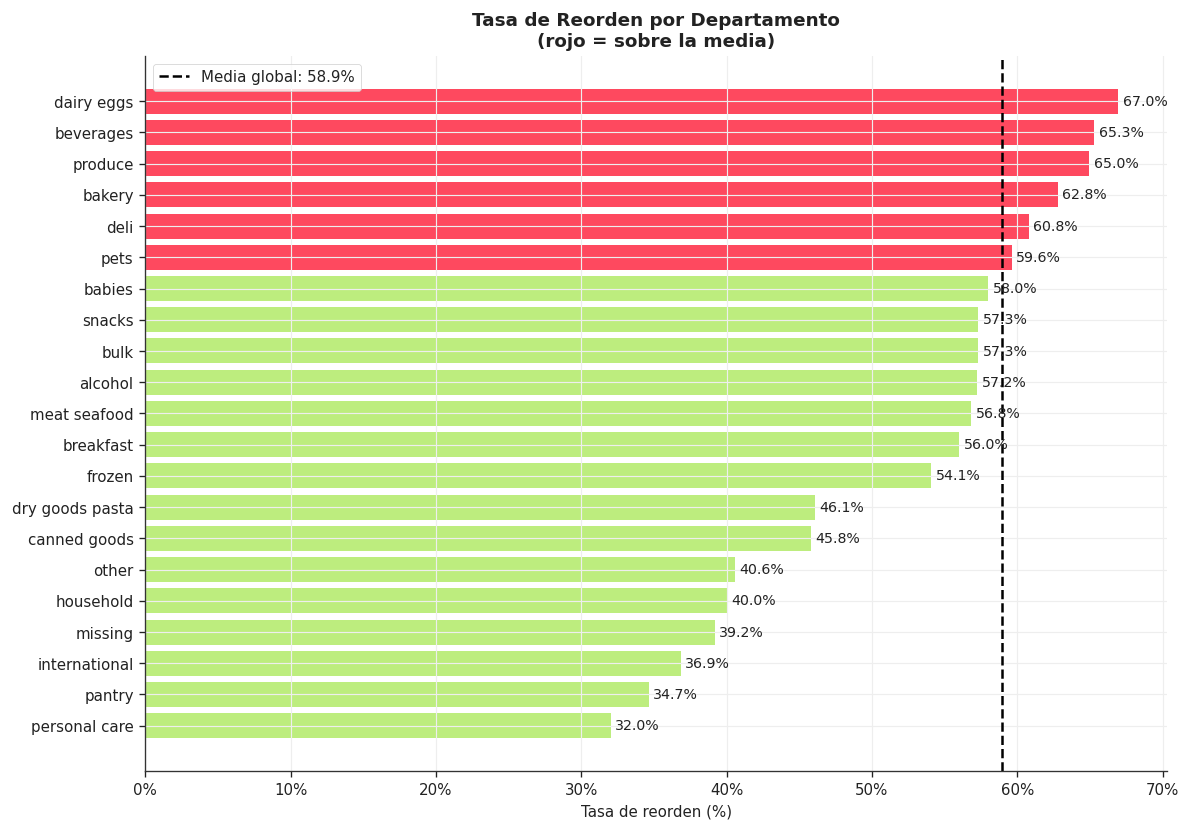

In [13]:
reorder_dept = (prior_full.groupby('department')['reordered']
                .agg(['mean','count']).rename(columns={'mean':'reorder_rate','count':'n_items'})
                .sort_values('reorder_rate'))
fig, ax = plt.subplots(figsize=(10, 7))
colors = [P[1] if v>global_reorder else P[0] for v in reorder_dept['reorder_rate']]
ax.barh(reorder_dept.index, reorder_dept['reorder_rate']*100, color=colors)
ax.axvline(global_reorder*100, color='black', lw=1.5, linestyle='--', label=f'Media global: {global_reorder:.1%}')
ax.set_title('Tasa de Reorden por Departamento\n(rojo = sobre la media)', fontweight='bold')
ax.set_xlabel('Tasa de reorden (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
for i,(idx,row) in enumerate(reorder_dept.iterrows()):
    ax.text(row['reorder_rate']*100+0.3, i, f"{row['reorder_rate']:.1%}", va='center', fontsize=8.5)
ax.legend(); plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/reorden_por_departamento.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Para entender cuántos productos cumplen con un mínimo histórico de compras (umbral) y cómo afecta esto al catálogo total:
for umbral in [10, 50, 100, 500, 1000]:
    n = (prior_full.groupby('product_id').size() >= umbral).sum()
    pct = n / prior_full['product_id'].nunique() * 100
    print(f'MIN_COMPRAS = {umbral:>5} → {n:>6,} productos ({pct:.1f}% del catálogo)')

MIN_COMPRAS =    10 → 39,561 productos (79.8% del catálogo)
MIN_COMPRAS =    50 → 23,530 productos (47.5% del catálogo)
MIN_COMPRAS =   100 → 17,270 productos (34.8% del catálogo)
MIN_COMPRAS =   500 →  6,668 productos (13.5% del catálogo)
MIN_COMPRAS =  1000 →  3,873 productos (7.8% del catálogo)


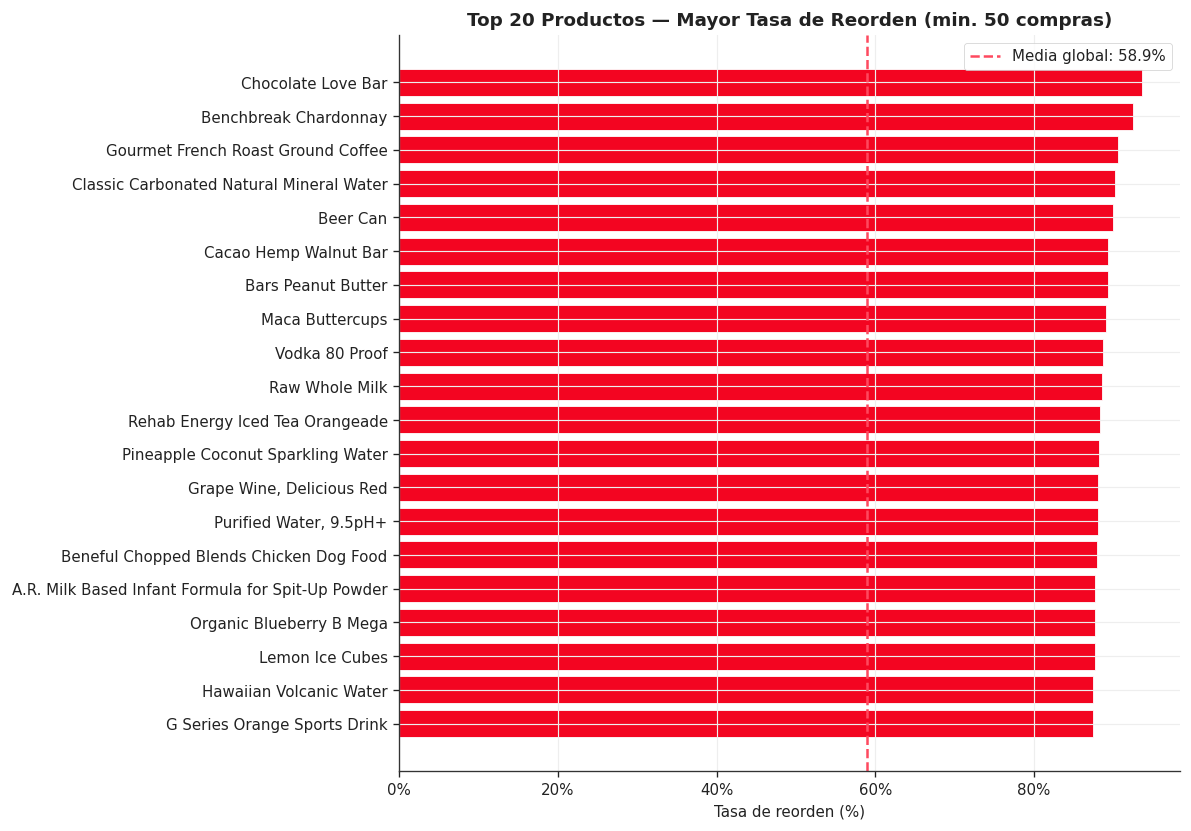

In [15]:
MIN_ORDERS = 50 # conserva 53.7% del catálogo — más de la mitad de los productos

prod_reorder = (prior_full.groupby('product_name')['reordered']
                .agg(['mean','count']).rename(columns={'mean':'reorder_rate','count':'n_orders'})
                .query('n_orders >= @MIN_ORDERS').sort_values('reorder_rate',ascending=False).head(20))
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(prod_reorder.index[::-1], prod_reorder['reorder_rate'][::-1]*100, color=P[2], edgecolor='white')
ax.axvline(global_reorder*100, color=P[1], lw=1.5, linestyle='--', label=f'Media global: {global_reorder:.1%}')
ax.set_title(f'Top 20 Productos — Mayor Tasa de Reorden (min. {MIN_ORDERS} compras)', fontweight='bold')
ax.set_xlabel('Tasa de reorden (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.legend(); plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/top20_productos_reorden.png', dpi=150, bbox_inches='tight')
plt.show()

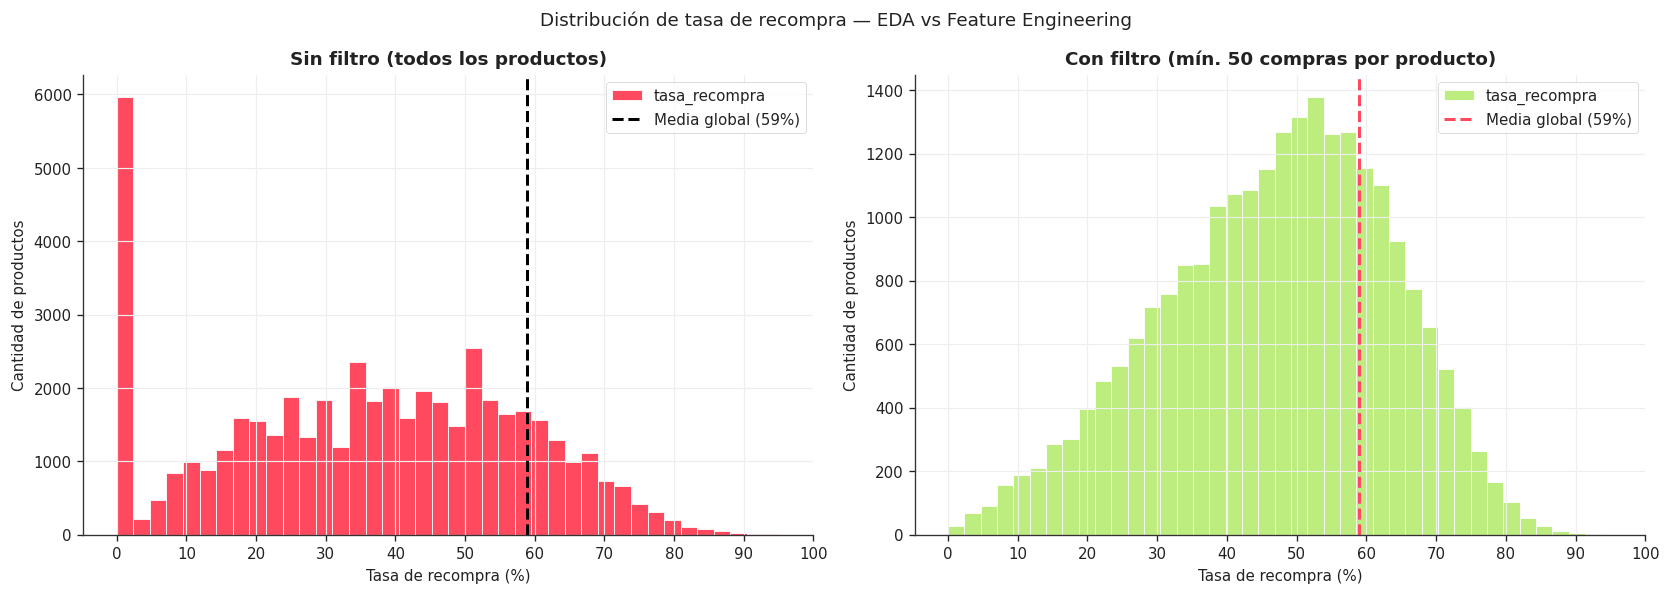

Productos sin filtro : 49,559
Productos con filtro : 23,530
Productos excluidos  : 26,029 (52.5%)


In [16]:
MIN_COMPRAS = 50  # según umbral para mantener el 53.7% del catálogo — más de la mitad de los productos

tasa_por_producto = (prior_full.groupby('product_id')['reordered']
                     .mean().reset_index()
                     .rename(columns={'reordered': 'tasa_recompra'}))

tasa_por_producto_filtrada = (prior_full.groupby('product_id')['reordered']
                               .agg(['mean', 'count'])
                               .rename(columns={'mean': 'tasa_recompra', 'count': 'total_compras'})
                               .query('total_compras >= @MIN_COMPRAS'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Sin filtro ────────────────────────────────────────────────────────────────
(tasa_por_producto['tasa_recompra'] * 100).plot(
    kind='hist', bins=40, color=P[1], edgecolor='white', ax=axes[0])
axes[0].set_title(f'Sin filtro (todos los productos)')
axes[0].set_xlabel('Tasa de recompra (%)')
axes[0].set_ylabel('Cantidad de productos')
axes[0].set_xticks(range(0, 101, 10))
axes[0].axvline(global_reorder * 100, color='black', linestyle='--',
                label=f'Media global ({global_reorder:.0%})')
axes[0].legend()

# ── Con filtro ────────────────────────────────────────────────────────────────
(tasa_por_producto_filtrada['tasa_recompra'] * 100).plot(
    kind='hist', bins=40, color=P[0], edgecolor='white', ax=axes[1])
axes[1].set_title(f'Con filtro (mín. {MIN_COMPRAS} compras por producto)')
axes[1].set_xlabel('Tasa de recompra (%)')
axes[1].set_ylabel('Cantidad de productos')
axes[1].set_xticks(range(0, 101, 10))
axes[1].axvline(global_reorder * 100, color=P[1], linestyle='--',
                label=f'Media global ({global_reorder:.0%})')
axes[1].legend()

plt.suptitle('Distribución de tasa de recompra — EDA vs Feature Engineering', fontsize=11)
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/distribucion_tasa_recompra.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Productos sin filtro : {len(tasa_por_producto):,}')
print(f'Productos con filtro : {len(tasa_por_producto_filtrada):,}')
print(f'Productos excluidos  : {len(tasa_por_producto) - len(tasa_por_producto_filtrada):,} ({(1 - len(tasa_por_producto_filtrada)/len(tasa_por_producto)):.1%})')

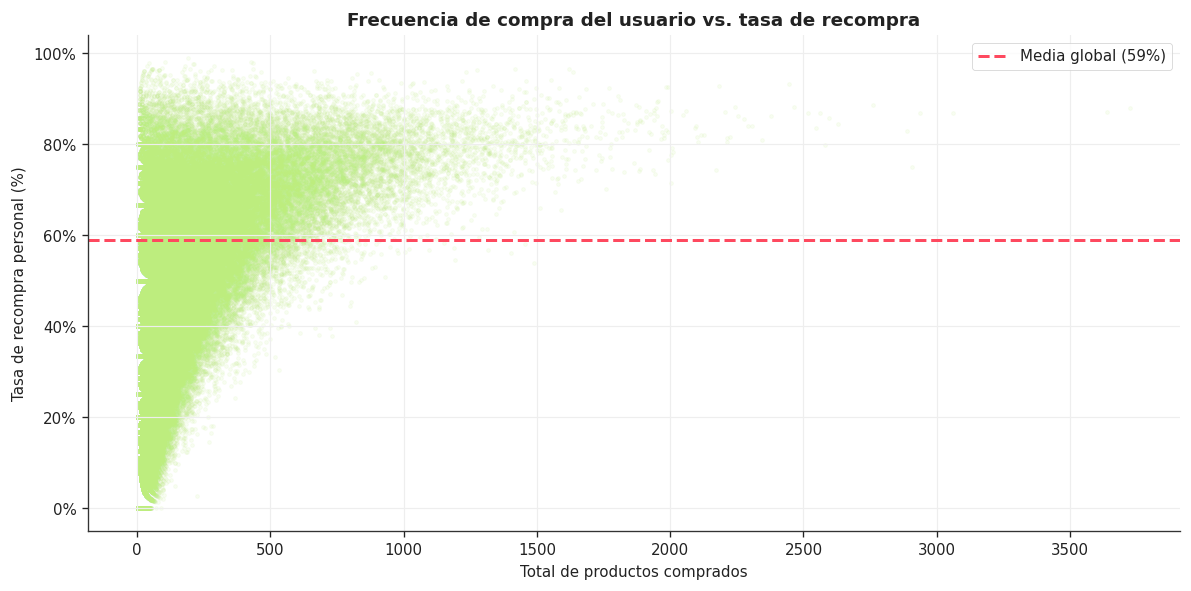

In [17]:
frecuencia_usuario = (prior_full.groupby('user_id')
                      .agg(total_productos=('product_id', 'count'),
                           tasa_recompra=('reordered', 'mean'))
                      .reset_index())

plt.figure(figsize=(10, 5))
plt.scatter(frecuencia_usuario['total_productos'],
            frecuencia_usuario['tasa_recompra'] * 100,
            alpha=0.1, color=P[0], s=5)
plt.axhline(global_reorder * 100, color=P[1], linestyle='--',
            label=f'Media global ({global_reorder:.0%})')
plt.title('Frecuencia de compra del usuario vs. tasa de recompra')
plt.xlabel('Total de productos comprados')
plt.ylabel('Tasa de recompra personal (%)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.legend()
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/frecuencia_vs_reorden_usuario.png', dpi=150, bbox_inches='tight')
plt.show()

### **Resultados — Sección 3**

### *Tasa global de recompra*
La tasa global de recompra es del **59%**. Esto significa que de cada
10 productos que aparecen en un carrito, casi 6 son productos que el
usuario ya compró antes. Este número es muy positivo para el proyecto:
una tasa alta de recompra implica que el comportamiento de compra es
bastante predecible y que el modelo tiene señal fuerte para trabajar.

### *Tasa de reorden por posicionamiento en el carrito*
Los **primeros ítems del carrito** tienen tasas de reorden >75% — `add_to_cart_order` captura hábito automatizado.

### *Tasa de recompra por departamento*
**Dairy eggs** encabeza la tasa de recompra con ~67%, seguido de
**beverages** (~65%) y **produce** (~65%). En el extremo opuesto,
**personal care** (~32%) y **pantry** (~38%) tienen tasas
significativamente menores.

Esto tiene lógica de negocio clara: la leche, el jugo y las frutas
son compras recurrentes casi automáticas, mientras que los productos
de cuidado personal o despensa se compran más esporádicamente o se
varían más entre compras.

**Implicancia para el modelo:** una feature de tasa de recompra
promedio por departamento puede ser útil como señal adicional para
el modelo. DS-2 puede considerar agregarla al feature matrix.

### *Top 20 productos más recomprados*
Los productos con mayor tasa de recompra superan el 90% e incluyen
productos de consumo recurrente: snacks, lácteos, alimentos para
mascotas y productos de limpieza. Estos productos tienen una demanda
casi automática — el usuario los compra casi todas las veces que hace
un pedido.

**Implicancia para el modelo:** estos productos son candidatos fuertes
para recomendaciones de alta precisión. Recomendar un producto con 95%
de tasa de recompra a un usuario que ya lo compró varias veces es casi
una recomendación garantizada.

### *Distribución de tasa de recompra por producto*
Los histogramas muestran dos realidades distintas del mismo catálogo. Sin filtro, el pico en 0% revela que casi la mitad de los productos tienen tan pocas compras que su tasa de recompra es estadísticamente irrelevante — un producto comprado 2 veces con 1 recompra aparece con 50% de tasa sin que eso refleje ningún patrón real. Al aplicar el filtro de 50 compras mínimas ese ruido desaparece y emerge una distribución normal centrada en 50-60%, consistente con la media global del 59%.

**Para DS-2**: usar MIN_COMPRAS = 50 al construir p_reorder_rate. Para los productos excluidos (46.3% del catálogo), imputar con la media del aisle como proxy — no descartarlos del espacio de candidatos.

**Implicancia para el modelo:** no hay una separación binaria clara entre
"productos que se recompran" y "productos que no". El modelo necesita
aprender a ordenar los productos por probabilidad de recompra para cada
usuario específico, no solo identificar los más populares globalmente.

### *Frecuencia de compra del usuario vs. tasa de recompra*
El scatterplot muestra una nube densa en la zona de pocos productos
comprados (usuarios con poco historial) con alta varianza en la tasa de
recompra. A medida que aumenta el historial del usuario, la tasa de
recompra se estabiliza en torno al 60-70%.

**Implicancia para el modelo:** los usuarios con más historial son más
predecibles. La feature `user_total_orders` captura indirectamente
esta confiabilidad — más órdenes implica más señal disponible.

---
## 3.1 Popularidad de Productos y Long Tail

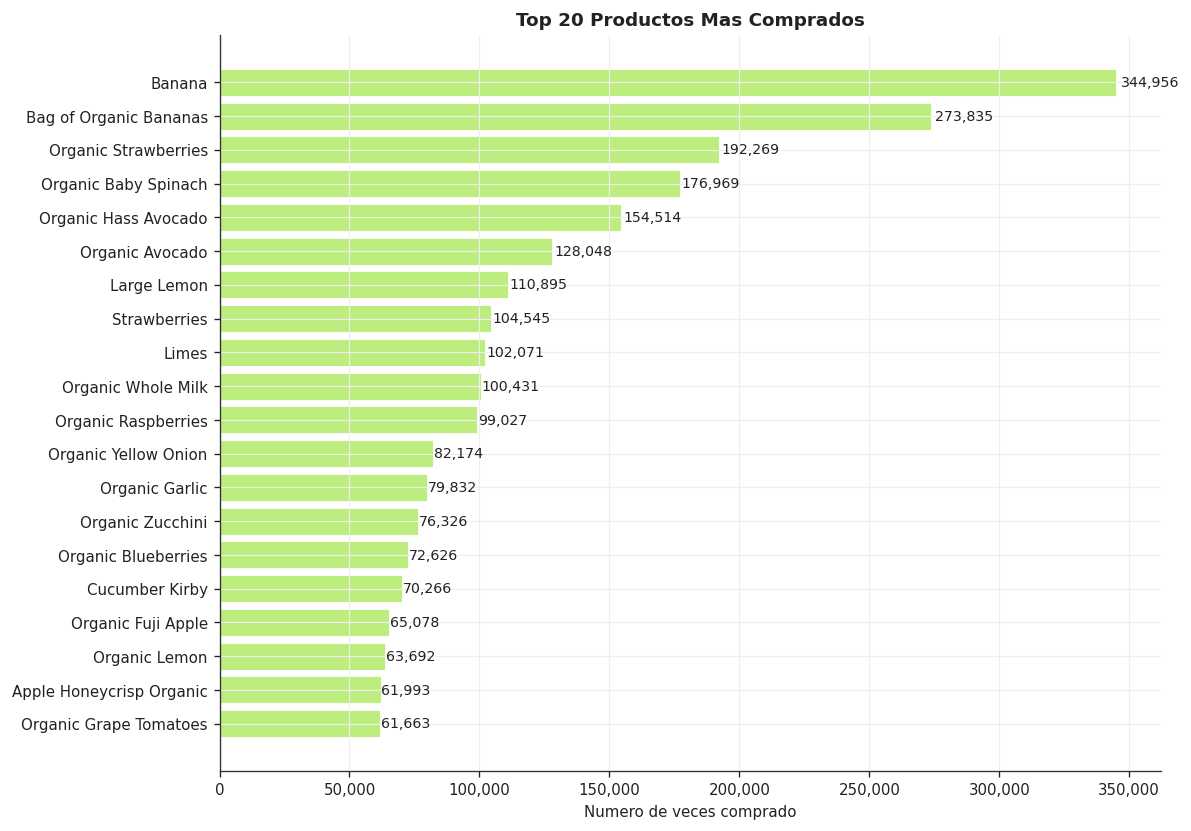

In [18]:
top_products = (prior_full.groupby('product_name')['order_id']
                .count().sort_values(ascending=False).head(20))
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_products.index[::-1], top_products.values[::-1], color=P[0], edgecolor='white')
ax.set_title('Top 20 Productos Mas Comprados', fontweight='bold')
ax.set_xlabel('Numero de veces comprado')
for i, val in enumerate(top_products.values[::-1]):
    ax.text(val*1.005, i, f'{val:,}', va='center', fontsize=8.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/top20_productos_comprados.png', dpi=150, bbox_inches='tight')
plt.show()

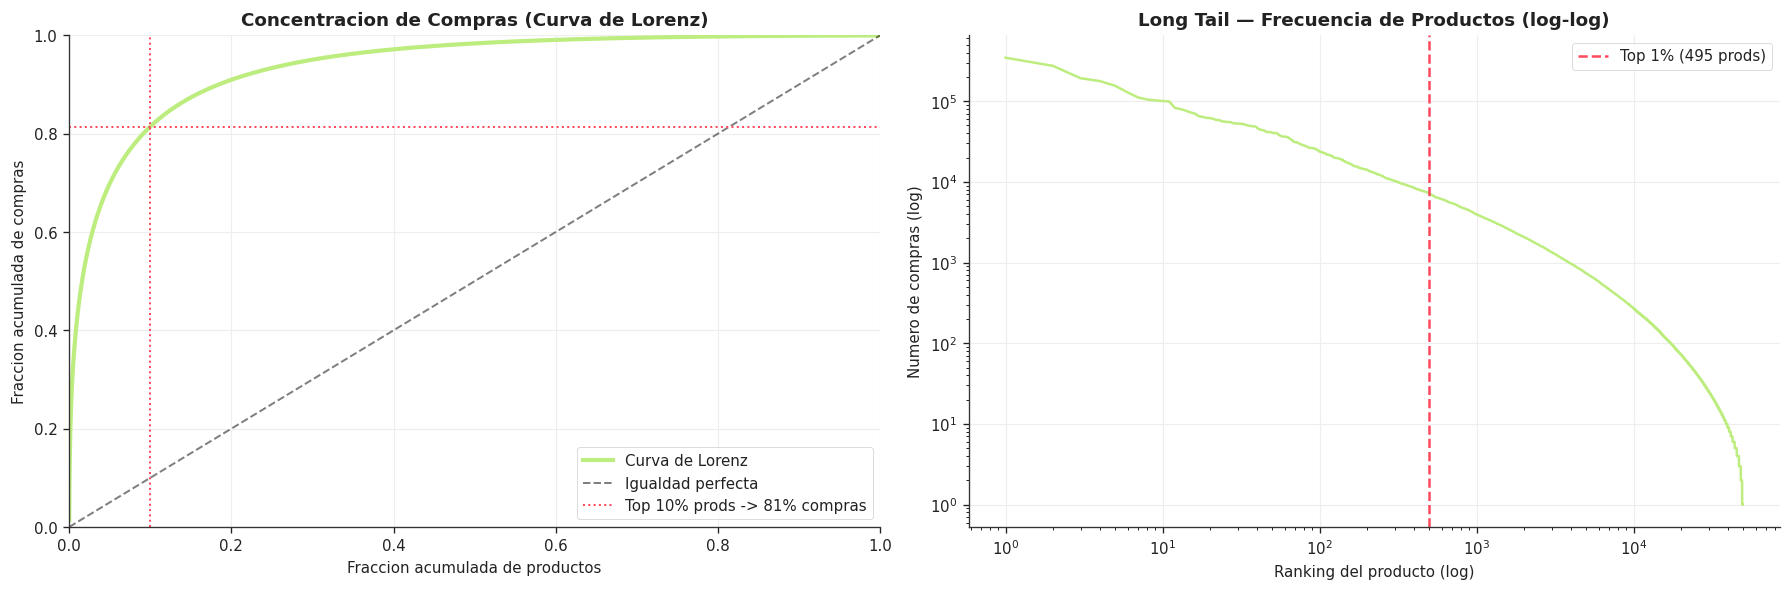

Top 1%  de productos -> 42.8% de todas las compras
Top 10% de productos -> 81.4% de todas las compras
Productos con solo 1 compra: 494 (1.0% del catalogo)


In [19]:
prod_freq  = prior_full.groupby('product_id').size().sort_values(ascending=False)
total      = prod_freq.sum()
cumulative = prod_freq.cumsum() / total
x          = np.linspace(0, 1, len(cumulative))
pct_top1   = prod_freq.head(int(len(prod_freq)*0.01)).sum() / total * 100
pct_top10  = prod_freq.head(int(len(prod_freq)*0.10)).sum() / total * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(x, cumulative.values, color=P[0], lw=2.5, label='Curva de Lorenz')
axes[0].plot([0,1],[0,1],'k--',lw=1.2,alpha=0.5,label='Igualdad perfecta')
axes[0].axvline(0.10,color=P[1],lw=1.2,linestyle=':')
axes[0].axhline(pct_top10/100,color=P[1],lw=1.2,linestyle=':',label=f'Top 10% prods -> {pct_top10:.0f}% compras')
axes[0].set_title('Concentracion de Compras (Curva de Lorenz)', fontweight='bold')
axes[0].set_xlabel('Fraccion acumulada de productos'); axes[0].set_ylabel('Fraccion acumulada de compras')
axes[0].legend(fontsize=9); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)

axes[1].loglog(range(1,len(prod_freq)+1), prod_freq.values, color=P[0], lw=1.5)
axes[1].axvline(len(prod_freq)*0.01,color=P[1],lw=1.5,linestyle='--',
                label=f'Top 1% ({int(len(prod_freq)*0.01):,} prods)')
axes[1].set_title('Long Tail — Frecuencia de Productos (log-log)', fontweight='bold')
axes[1].set_xlabel('Ranking del producto (log)'); axes[1].set_ylabel('Numero de compras (log)')
axes[1].legend(fontsize=9)
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/curva_lorenz_productos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Top 1%  de productos -> {pct_top1:.1f}% de todas las compras')
print(f'Top 10% de productos -> {pct_top10:.1f}% de todas las compras')
print(f'Productos con solo 1 compra: {(prod_freq==1).sum():,} ({(prod_freq==1).mean():.1%} del catalogo)')

###  **Resultados — Sección 3.1**

- #### *Top 20 productos mas comprados*
El top 20 de productos más comprados está dominado casi exclusivamente por frescos y orgánicos — Banana lidera con 472,565 compras, seguida por Bag of Organic Bananas con 379,450. De los 20 productos, más de 15 son frutas, verduras u orgánicos. Son productos perecederos de consumo diario con ciclos de reposición cortos, lo que explica naturalmente su alta frecuencia de compra y recompra.

- #### *Concentración de compras*
La curva de Lorenz confirma una concentración extrema: el top 10% de productos (aproximadamente 496 productos sobre ~49,000) explica el 81% de todas las compras del dataset. La curva se aleja drásticamente de la línea de igualdad perfecta, lo que indica que el catálogo está muy lejos de una distribución uniforme.

- #### *Long Tail*
El gráfico log-log lo hace aún más evidente — la caída es pronunciada y sostenida. A partir del producto número 500 aproximadamente, el volumen de compras cae varios órdenes de magnitud. Esto es la materialización visual del problema de long tail: unos pocos productos concentran casi todo el volumen, mientras que la gran mayoría del catálogo tiene actividad marginal.

**Esta estructura tiene una implicación directa para el modelo: optimizar bien las recomendaciones para el top 10% del catálogo captura el 81% del impacto posible. La cola larga es el escenario donde el modelo va a tener más dificultad — y donde el problema de cold start se vuelve crítico, como se analiza en la Sección 5.**

---
## 4. Productos y Categorías
Analizar las compras por categoría de producto permite identificar patrones diferentes dentro del catálogo. En e-commerce, la estructura jerárquica (departamento → pasillo → producto) ayuda a crear variables agregadas que mejoran el sistema de recomendación.

Algunas categorías, como lácteos o frutas, tienen tasas de recompra más altas porque se compran con mayor frecuencia, mientras que otras se compran solo ocasionalmente. Estas diferencias hacen útil incluir variables a nivel de categoría en el modelo.

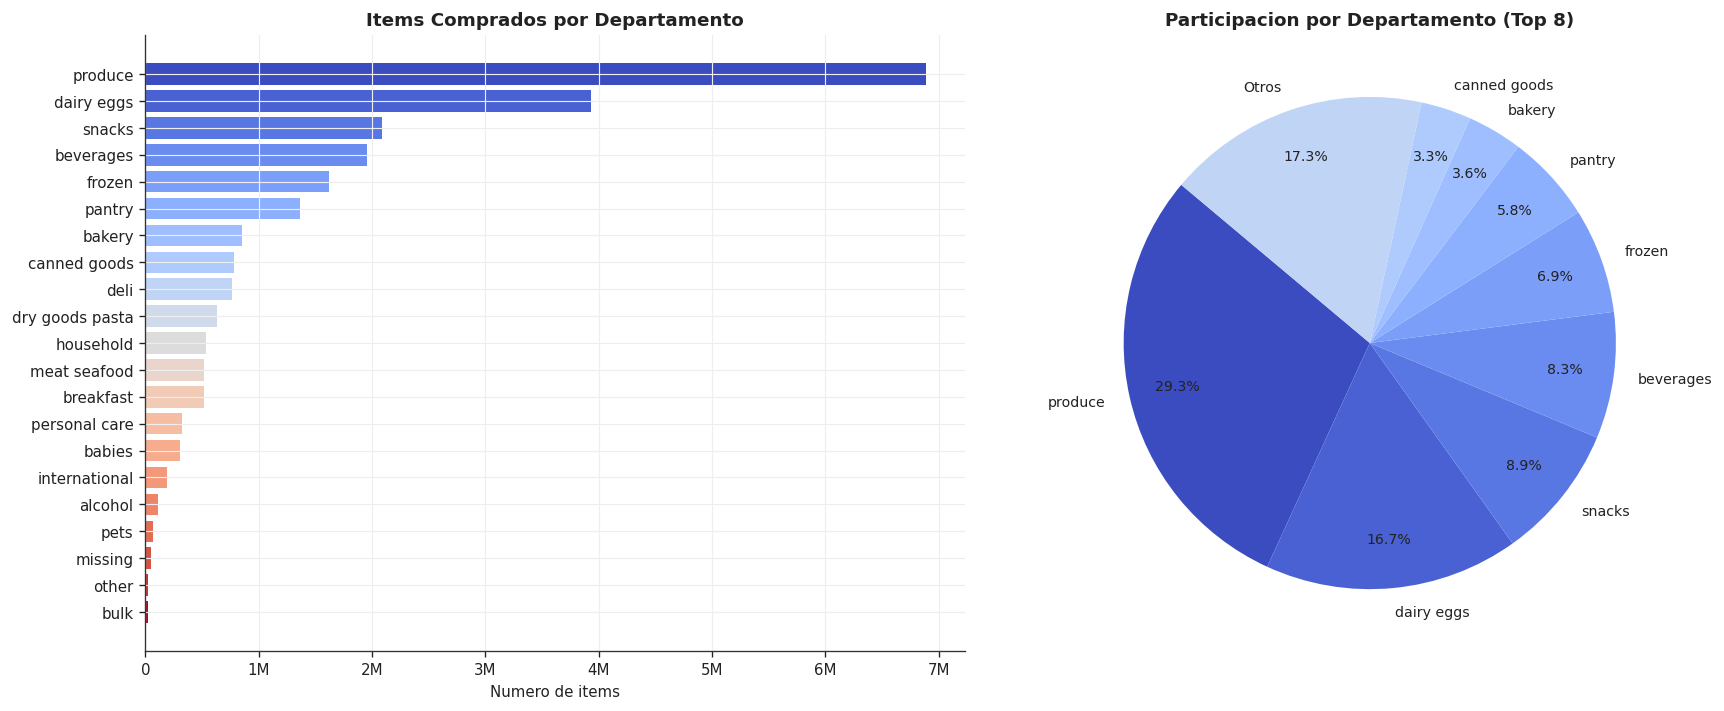

In [21]:
dept_counts = departments

colors = plt.cm.coolwarm(np.linspace(0, 1, len(dept_counts)))

dept_counts = prior_full.groupby('department')['order_id'].count().sort_values(ascending=False)
fig, axes   = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(dept_counts.index[::-1], dept_counts.values[::-1], color=colors[::-1])
axes[0].set_title('Items Comprados por Departamento', fontweight='bold')
axes[0].set_xlabel('Numero de items')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x/1e6):.0f}M' if x>=1e6 else f'{int(x):,}'))

top8 = dept_counts.head(8)
pie_data = pd.concat([top8, pd.Series({'Otros': dept_counts.iloc[8:].sum()})])
axes[1].pie(pie_data.values, labels=pie_data.index, colors=colors, autopct='%1.1f%%',
            startangle=140, pctdistance=0.8, textprops={'fontsize':8.5})
axes[1].set_title('Participacion por Departamento (Top 8)', fontweight='bold')
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/compras_por_departamento.png', dpi=150, bbox_inches='tight')
plt.show()

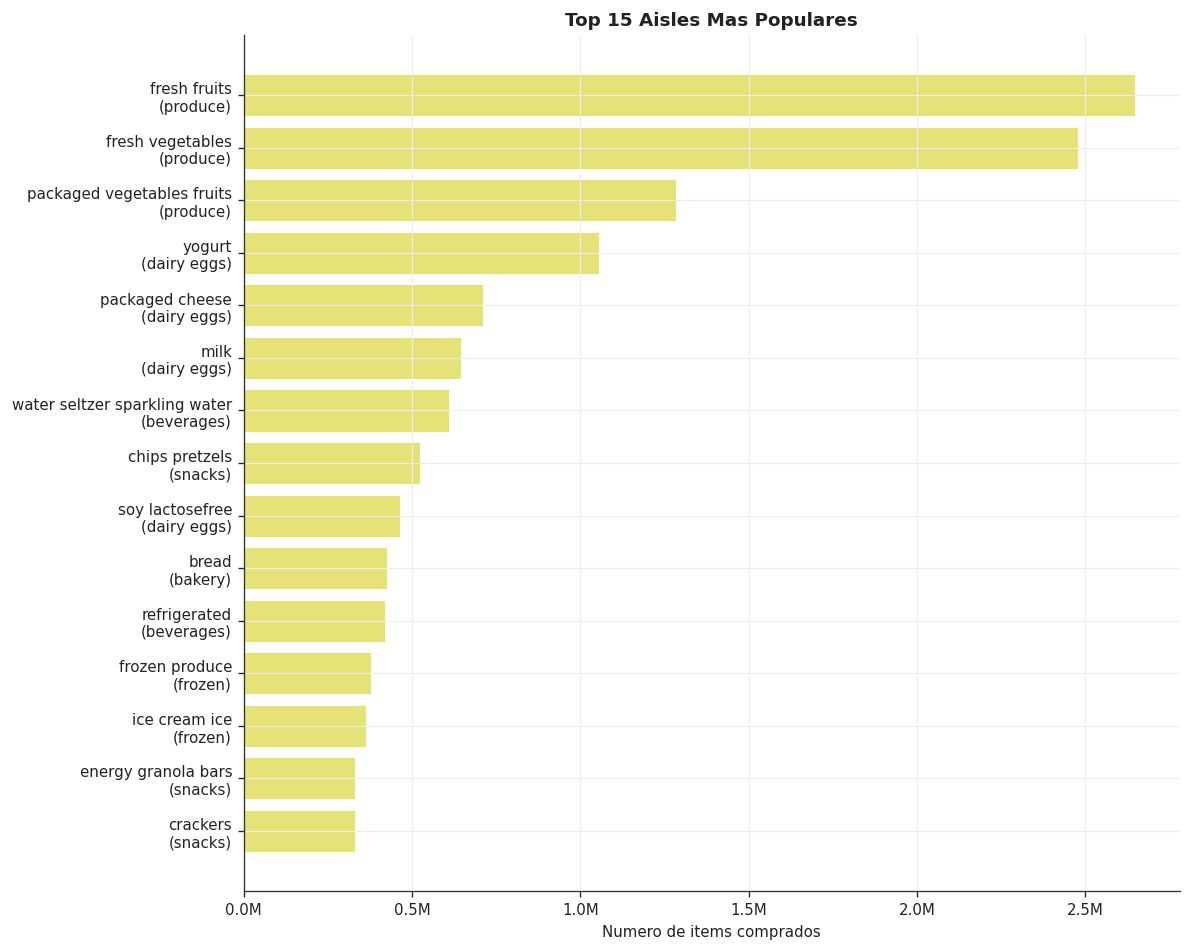

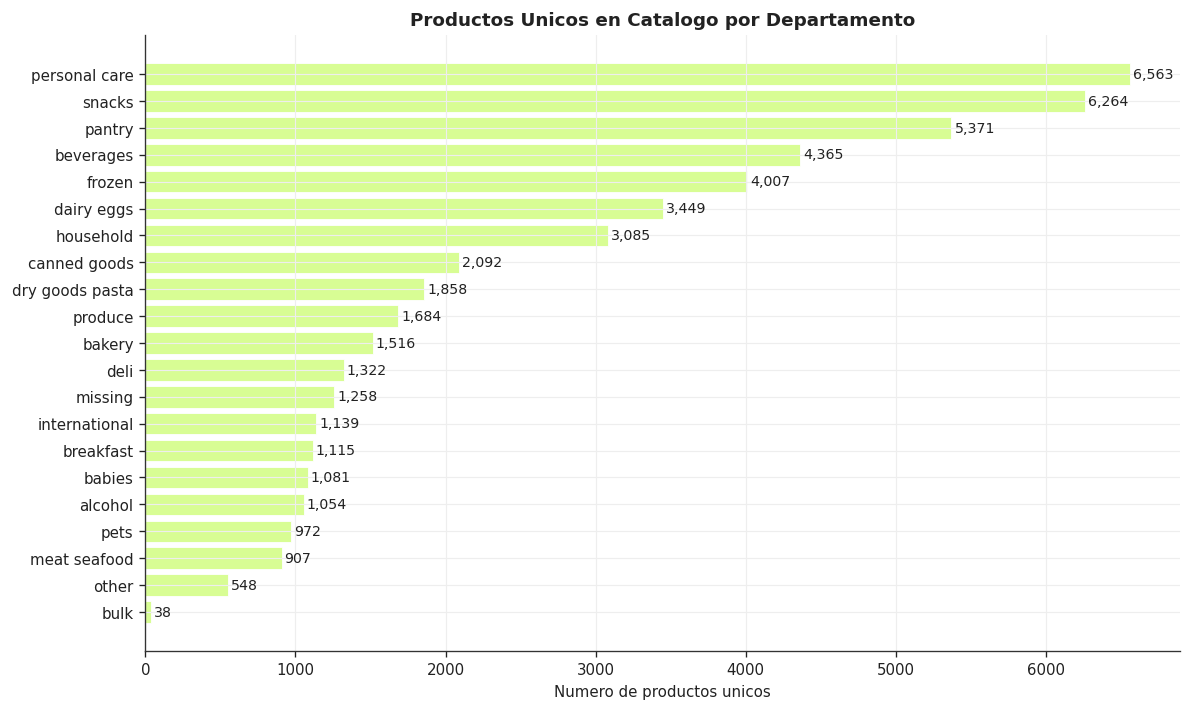

In [22]:
top_aisles = (prior_full.groupby(['department','aisle'])['order_id']
              .count().sort_values(ascending=False).head(15).reset_index())
top_aisles['label'] = top_aisles['aisle'] + '\n(' + top_aisles['department'] + ')'
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_aisles['label'][::-1], top_aisles['order_id'][::-1], color=P[3], edgecolor='white')
ax.set_title('Top 15 Aisles Mas Populares', fontweight='bold')
ax.set_xlabel('Numero de items comprados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/top15_aisles.png', dpi=150, bbox_inches='tight')
plt.show()

catalog_rich = products_full.groupby('department')['product_id'].count().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(catalog_rich.index[::-1], catalog_rich.values[::-1], color=P[5], edgecolor='white')
ax.set_title('Productos Unicos en Catalogo por Departamento', fontweight='bold')
ax.set_xlabel('Numero de productos unicos')
for i, val in enumerate(catalog_rich.values[::-1]):
    ax.text(val+20, i, f'{val:,}', va='center', fontsize=8.5)
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/top15_aisles.png', dpi=150, bbox_inches='tight')
plt.show()

###  **Resultados — Sección 4**

- #### *Compras por departamento*
Produce (29.2%) y dairy eggs (16.7%) concentran casi la mitad de todas las compras, liderados por fresh fruits y fresh vegetables con más de 3.5M compras cada uno.

- #### *Productos únicos por departamento*
La inversión es llamativa cuando miramos los productos únicos por categoría: personal care (6,563 productos) y snacks (6,264) tienen los catálogos más grandes pero volúmenes de compra bajos. Produce, que domina en volumen, tiene solo 1,684 productos únicos.

Esta asimetría genera **sparsity diferencial por categoría** — para personal care y snacks la matriz usuario-producto será extremadamente dispersa, mientras que para produce será relativamente densa. El modelo necesita tratar estas categorías de manera diferente al construir features y manejar cold start.

---
## 4.1 Perfiles de Usuario y Cohortes

En esta sección segmentamos a los usuarios según su frecuencia de compra y analizamos cómo evoluciona su comportamiento a lo largo del tiempo. El objetivo es entender si existen perfiles de usuario diferenciados y si esos perfiles tienen patrones de recompra distintos — información clave para decidir cómo ponderar los ejemplos de entrenamiento en DS-2.

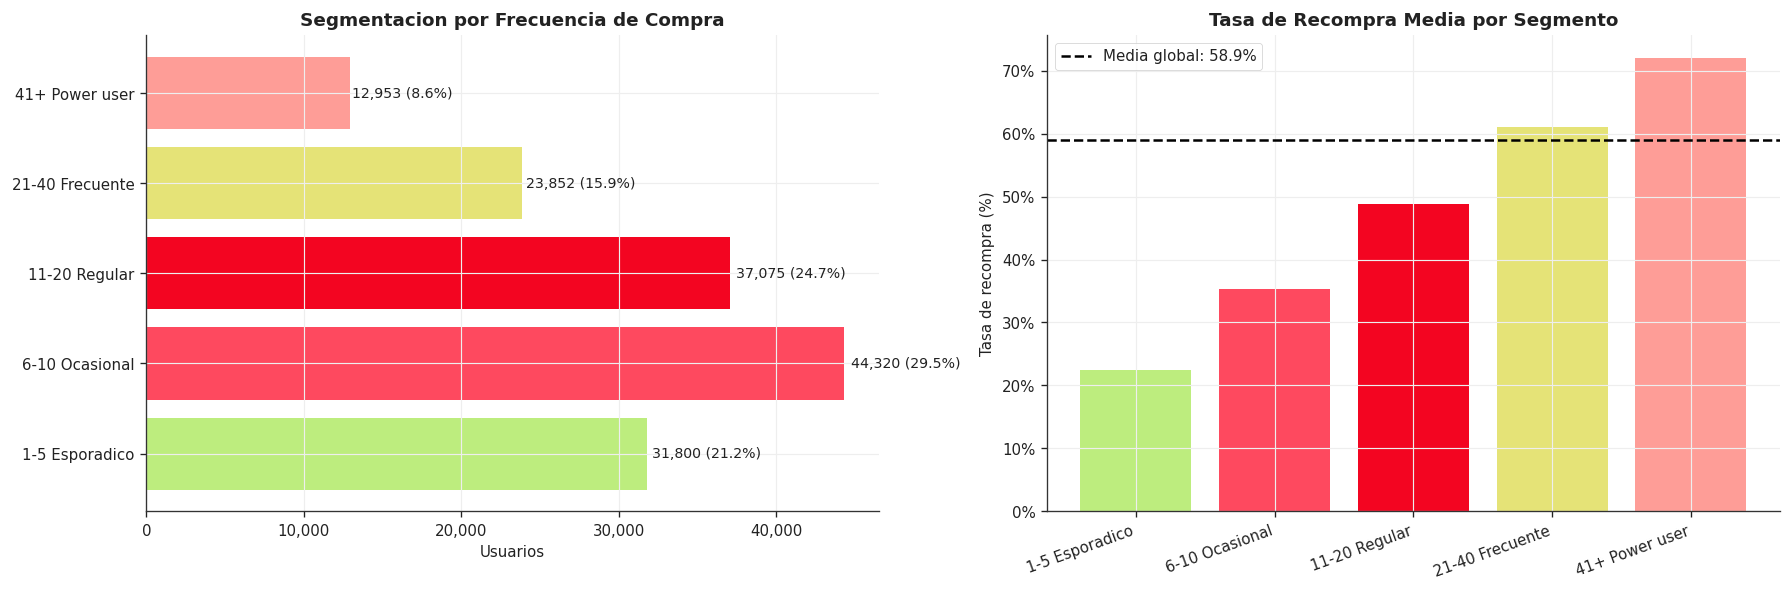

In [23]:
bins   = [0,5,10,20,40,100]
labels = ['1-5 Esporadico','6-10 Ocasional','11-20 Regular','21-40 Frecuente','41+ Power user']
user_segments = pd.cut(orders_per_user, bins=bins, labels=labels)
seg_counts    = user_segments.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bars = axes[0].barh(seg_counts.index, seg_counts.values, color=P[:5])
axes[0].set_title('Segmentacion por Frecuencia de Compra', fontweight='bold')
axes[0].set_xlabel('Usuarios')
for bar, val in zip(bars, seg_counts.values):
    pct = val/seg_counts.sum()*100
    axes[0].text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                 f'{val:,} ({pct:.1f}%)', va='center', fontsize=8.5)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

user_reorder = prior_full.groupby('user_id')['reordered'].mean().rename('reorder_rate')
seg_df   = pd.DataFrame({'segment':user_segments,'reorder_rate':user_reorder}).dropna()
seg_mean = seg_df.groupby('segment',observed=True)['reorder_rate'].mean()
axes[1].bar(seg_mean.index, seg_mean.values*100, color=P[:5])
axes[1].axhline(global_reorder*100, color='black', lw=1.5, linestyle='--', label=f'Media global: {global_reorder:.1%}')
axes[1].set_title('Tasa de Recompra Media por Segmento', fontweight='bold')
axes[1].set_ylabel('Tasa de recompra (%)')
axes[1].set_xticklabels(seg_mean.index, rotation=20, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
axes[1].legend()
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/segmentacion_usuarios.png', dpi=150, bbox_inches='tight')
plt.show()

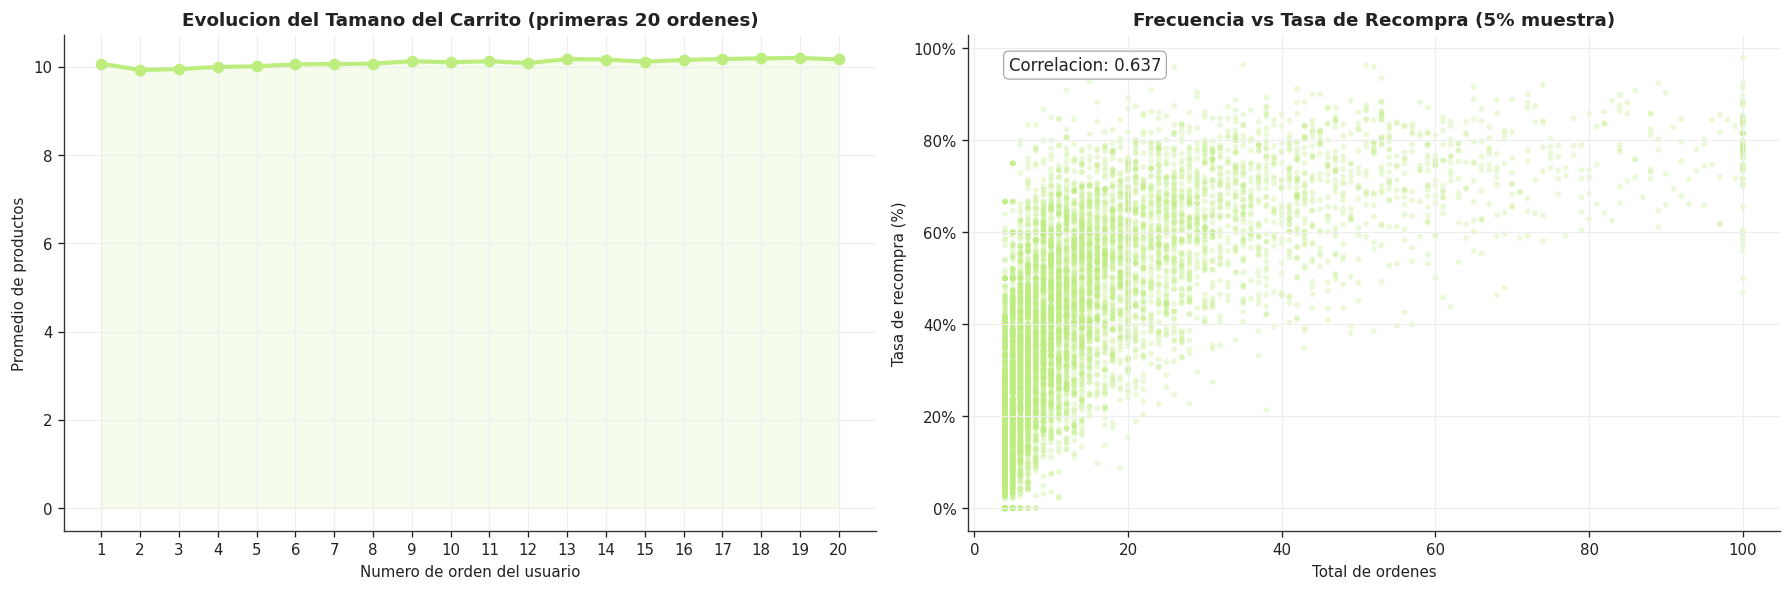

In [24]:
cohort      = (prior_full.groupby(['user_id','order_number'])['product_id']
               .count().reset_index().rename(columns={'product_id':'cart_size'}))
cohort_mean = cohort[cohort['order_number']<=20].groupby('order_number')['cart_size'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(cohort_mean.index, cohort_mean.values, marker='o', color=P[0], lw=2.5, markersize=6)
axes[0].fill_between(cohort_mean.index, cohort_mean.values, alpha=0.15, color=P[0])
axes[0].set_title('Evolucion del Tamano del Carrito (primeras 20 ordenes)', fontweight='bold')
axes[0].set_xlabel('Numero de orden del usuario'); axes[0].set_ylabel('Promedio de productos')
axes[0].set_xticks(range(1,21))

user_stats = (
    prior_full.groupby('user_id').agg(reorder_rate=('reordered','mean')).reset_index()
    .merge(orders_per_user.rename('total_orders'), on='user_id')
)
sample = user_stats.sample(frac=0.05, random_state=42)
sc = axes[1].scatter(sample['total_orders'], sample['reorder_rate']*100,
                     alpha=0.3, s=12, color=P[0], edgecolors='none')
corr = user_stats['total_orders'].corr(user_stats['reorder_rate'])
axes[1].set_title('Frecuencia vs Tasa de Recompra (5% muestra)', fontweight='bold')
axes[1].set_xlabel('Total de ordenes'); axes[1].set_ylabel('Tasa de recompra (%)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
axes[1].text(0.05, 0.93, f'Correlacion: {corr:.3f}', transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/cohort_tamanio_carrito.png', dpi=150, bbox_inches='tight')
plt.show()

###  **Resultados — Sección 4.1**

- #### *Segmentación por frecuencia de compra*
La segmentación muestra que el grueso de los usuarios cae en los segmentos Ocasional (29.6%) y Regular (24.7%), mientras que los power users representan solo el 8.7% — pero son los más valiosos para el modelo porque su comportamiento es el más predecible.

- #### *Tasa de recompra media por segmento*
La relación entre frecuencia y tasa de recompra es clara y progresiva: los usuarios esporádicos tienen apenas un 22% de recompra, mientras que los power users superan el 70%. A mayor historial, más predecible es el usuario.

- #### *Evolución del tamaño del carrito*
El gráfico de evolución del tamaño de cesta revela algo llamativo: el tamaño se estabiliza casi desde la primera orden en ~10 productos y no varía en las siguientes 20. Los usuarios llegan con un tamaño de cesta definido y lo mantienen — no hay un período de "calentamiento".
- #### *Frecuencia vs tasa de recompra*
El scatter confirma la correlación de 0.637 entre frecuencia y tasa de recompra — positiva y moderada. La dispersión vertical es alta, especialmente en usuarios con pocas órdenes, lo que indica que la frecuencia sola no explica todo. Ambas métricas aportan señal independiente y deben usarse como features separadas en DS-2.

---
## 5. Sparsity y Cold Start
La sparsity de la matriz usuario-producto y el problema de cold start son desafíos comunes en los sistemas de recomendación. En datasets de e-commerce es normal que la mayoría de las combinaciones usuario-producto no tengan interacción.

Esta alta dispersión influye en la elección del modelo: algunos métodos necesitan más datos para aprender bien, mientras que modelos basados en árboles suelen manejar mejor datos dispersos.

El cold start ocurre cuando un usuario tiene muy pocas compras registradas. En este análisis se consideran usuarios sparse aquellos con menos de 5 órdenes, ya que con tan poco historial es difícil estimar bien sus preferencias.

Usuarios unicos              :    150,000
Productos unicos (en prior)  :     49,559
Pares (user,product) vistos  :  9,662,673
Pares posibles               : 7,433,850,000
Sparsity                     : 0.998700  (99.8700%)
Solo el 0.1300% de la matriz user-item esta rellena.


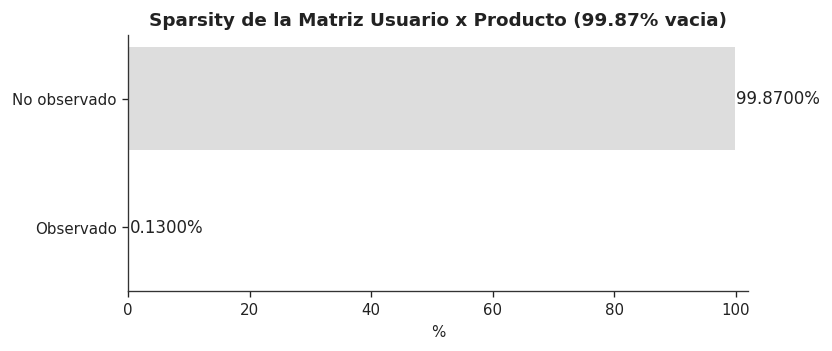

In [25]:
n_users_s    = prior_full['user_id'].nunique()
n_products_s = prior_full['product_id'].nunique()
n_observed   = prior_full.groupby(['user_id','product_id']).ngroups
n_possible   = n_users_s * n_products_s
sparsity     = 1 - n_observed / n_possible

print(f'Usuarios unicos              : {n_users_s:>10,}')
print(f'Productos unicos (en prior)  : {n_products_s:>10,}')
print(f'Pares (user,product) vistos  : {n_observed:>10,}')
print(f'Pares posibles               : {n_possible:>10,}')
print(f'Sparsity                     : {sparsity:.6f}  ({sparsity*100:.4f}%)')
print(f'Solo el {(1-sparsity)*100:.4f}% de la matriz user-item esta rellena.')

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(['Observado','No observado'], [(1-sparsity)*100, sparsity*100], color=[P[0],'#DDDDDD'])
ax.set_title(f'Sparsity de la Matriz Usuario x Producto ({sparsity*100:.2f}% vacia)', fontweight='bold')
ax.set_xlabel('%')
for i, val in enumerate([(1-sparsity)*100, sparsity*100]):
    ax.text(val+0.2, i, f'{val:.4f}%', va='center', fontsize=10)
ax.set_xlim(0,102); ax.grid(False)
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/sparsity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

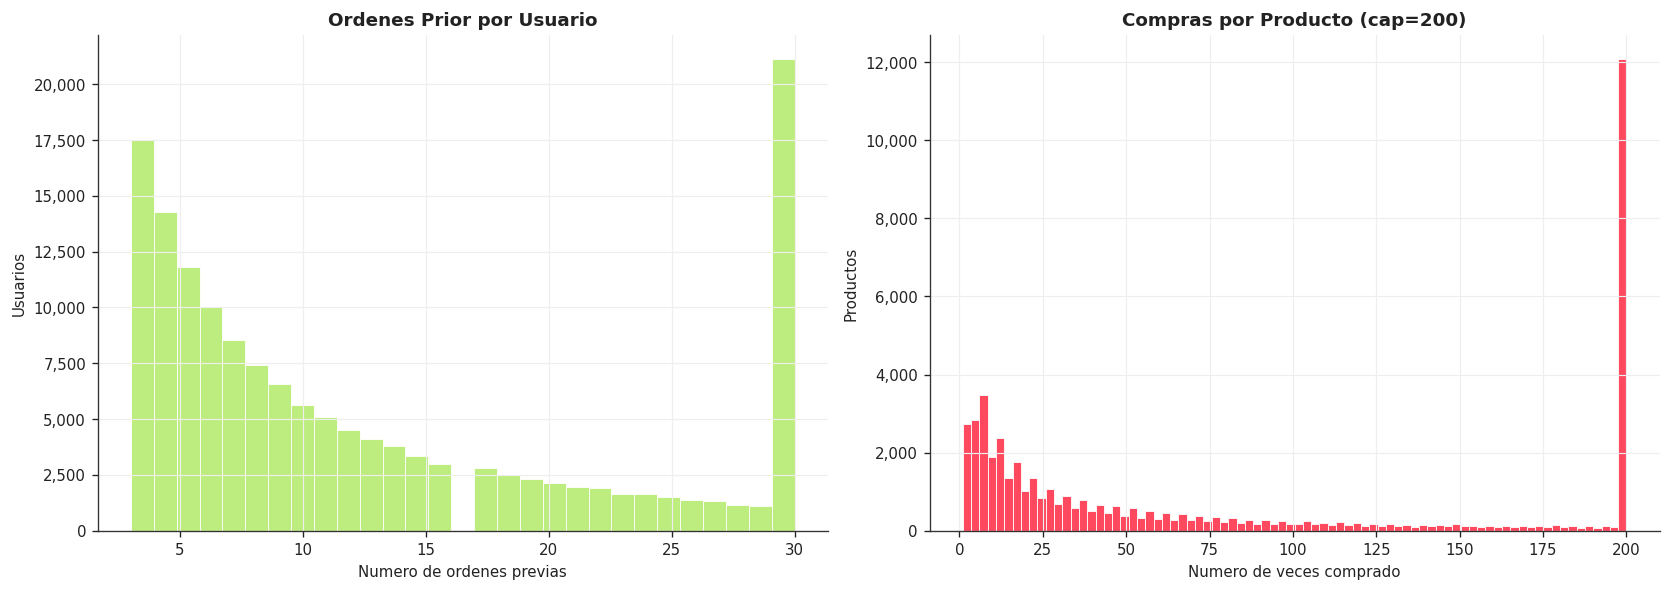

Cold start de USUARIOS (usuarios con <= N ordenes en prior):
  <= 1 ordenes: 0 (0.0%)
  <= 2 ordenes: 0 (0.0%)
  <= 3 ordenes: 17,510 (11.7%)
  <= 5 ordenes: 43,613 (29.1%)

Cold start de PRODUCTOS (con <= N compras totales):
  <=  1 compras: 494 (1.0%)
  <=  5 compras: 5,573 (11.2%)
  <= 10 compras: 10,932 (22.1%)
  <= 20 compras: 17,407 (35.1%)


In [26]:
prior_orders_count   = orders[orders['eval_set']=='prior'].groupby('user_id')['order_id'].count()
prod_purchase_count  = prior_full.groupby('product_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(prior_orders_count.clip(upper=30), bins=29, color=P[0], edgecolor='white')
axes[0].set_title('Ordenes Prior por Usuario', fontweight='bold')
axes[0].set_xlabel('Numero de ordenes previas'); axes[0].set_ylabel('Usuarios')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

axes[1].hist(prod_purchase_count.clip(upper=200), bins=80, color=P[1], edgecolor='white')
axes[1].set_title('Compras por Producto (cap=200)', fontweight='bold')
axes[1].set_xlabel('Numero de veces comprado'); axes[1].set_ylabel('Productos')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/ordenes_prior_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

print('Cold start de USUARIOS (usuarios con <= N ordenes en prior):')
for t in [1,2,3,5]:
    n = (prior_orders_count<=t).sum()
    print(f'  <= {t} ordenes: {n:,} ({n/len(prior_orders_count):.1%})')
print('\nCold start de PRODUCTOS (con <= N compras totales):')
for t in [1,5,10,20]:
    n = (prod_purchase_count<=t).sum()
    print(f'  <= {t:2d} compras: {n:,} ({n/len(prod_purchase_count):.1%})')

Cobertura del catalogo:
  En catalogo total  : 49,688
  En prior           : 49,559 (99.7%)
  En train           : 36,617 (73.7%)
  En prior Y train   : 36,586 (73.6%)
  Nunca comprados    : 129 (0.3%)


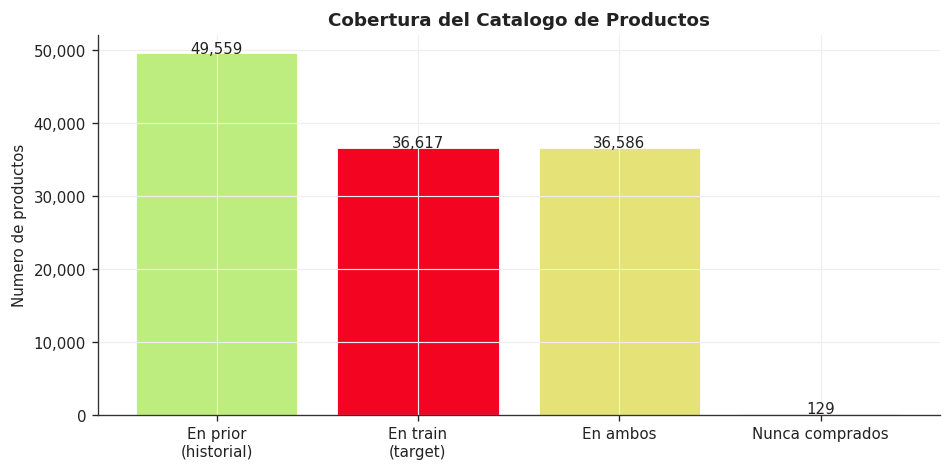

In [27]:
p_prior   = set(order_prior['product_id'].unique())
p_train   = set(order_train['product_id'].unique())
p_catalog = set(products['product_id'].unique())
in_both        = p_prior & p_train
only_in_catalog = p_catalog - p_prior

print('Cobertura del catalogo:')
print(f'  En catalogo total  : {len(p_catalog):,}')
print(f'  En prior           : {len(p_prior):,} ({len(p_prior)/len(p_catalog):.1%})')
print(f'  En train           : {len(p_train):,} ({len(p_train)/len(p_catalog):.1%})')
print(f'  En prior Y train   : {len(in_both):,} ({len(in_both)/len(p_catalog):.1%})')
print(f'  Nunca comprados    : {len(only_in_catalog):,} ({len(only_in_catalog)/len(p_catalog):.1%})')

fig, ax = plt.subplots(figsize=(8, 4))
cats = ['En prior\n(historial)','En train\n(target)','En ambos','Nunca comprados']
vals = [len(p_prior),len(p_train),len(in_both),len(only_in_catalog)]
bars = ax.bar(cats, vals, color=[P[0],P[2],P[3],P[1]], edgecolor='white')
ax.set_title('Cobertura del Catalogo de Productos', fontweight='bold')
ax.set_ylabel('Numero de productos')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{val:,}', ha='center', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/cobertura_catalogo.png', dpi=150, bbox_inches='tight')
plt.show()

###  **Resultados — Sección 5**

#### *Sparsity*
La matriz usuario-producto tiene **sparsity >99.9%**.
De todos los pares (usuario, producto) posibles, solo una fracción muy
pequeña fue observada. Esta es la sparsity esperada y típica en datasets
de e-commerce: ningún usuario compra todos los productos del catálogo.

Esta alta sparsity justifica el enfoque elegido — usar un modelo
supervisado con features de interacción (LightGBM) en lugar de
filtrado colaborativo basado en factorización de matrices, que sufre
mucho con matrices muy dispersas.

#### *Cold start*
El histograma con cap en 50 órdenes muestra que una porción importante
de los usuarios tiene menos de 5 órdenes. Para estos usuarios el modelo
tiene muy poca información disponible para construir features confiables.

Subconjunto de productos nunca comprados son candidatos a excluir del espacio de predicción.

**Implicancia para el modelo:** DS-2 debe manejar los nulos que surgen
para usuarios con 1 sola orden en features como `user_avg_days_between_orders`
(no tienen orden anterior). Una estrategia es imputar con la mediana
global del dataset para esos casos.

---
## 5.1 Co-ocurrencia y Preview de Features
Esta sección tiene dos objetivos concretos. Primero, explorar la co-ocurrencia entre productos — qué pares de productos tienden a comprarse juntos en la misma orden — como señal complementaria que el modelo puede aprovechar implícitamente. Segundo, construir y validar el conjunto de features que alimentará DS-2: un preview de las tablas user_features, prod_features y up_features que se generan a partir de todo el análisis previo.



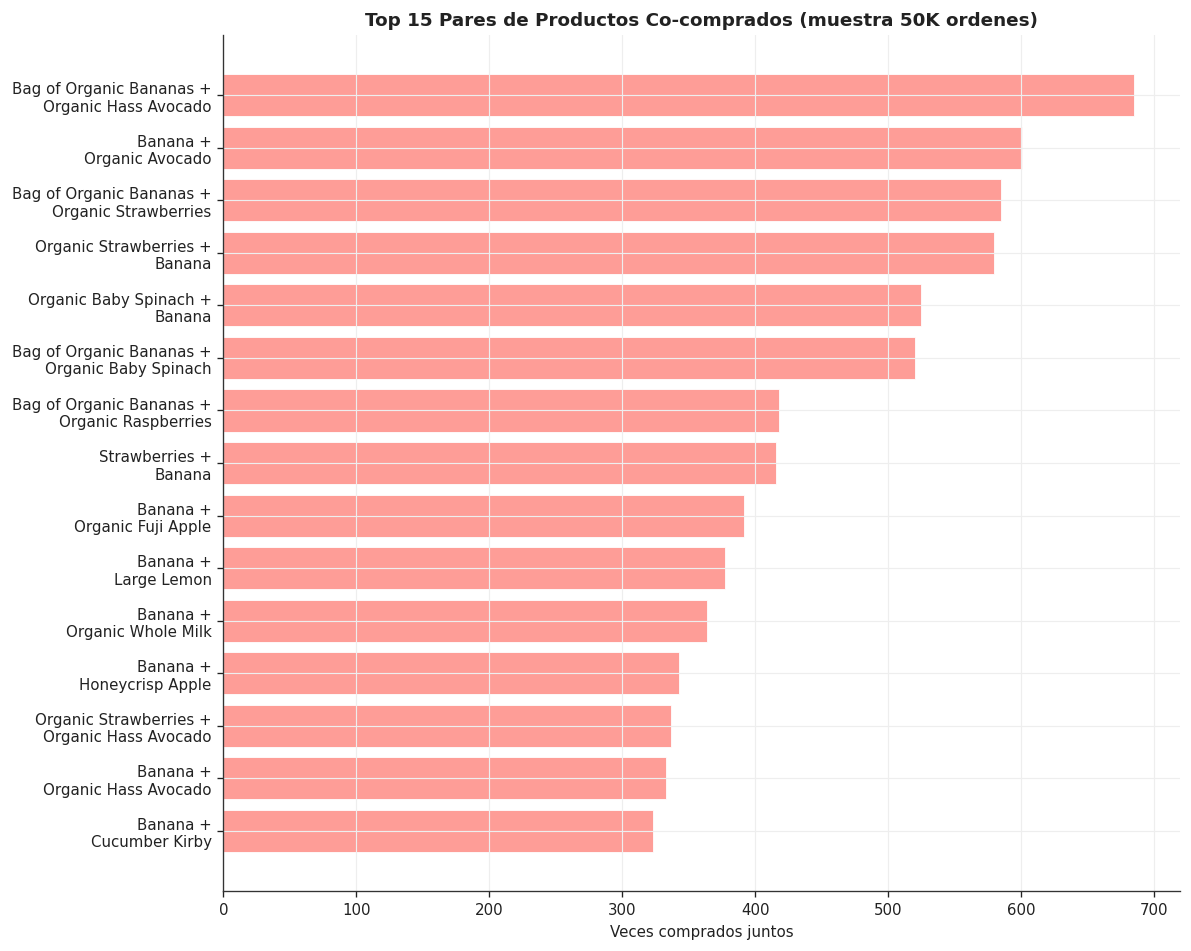

In [28]:
sample_orders = prior_full.groupby('order_id')['product_id'].apply(list)
sample_orders = sample_orders[sample_orders.apply(len)>=2].sample(min(50000,len(sample_orders)), random_state=42)

pair_counts = Counter()
for items in sample_orders:
    for pair in combinations(sorted(items[:10]), 2):
        pair_counts[pair] += 1

top_pairs  = pair_counts.most_common(15)
id2name    = products.set_index('product_id')['product_name'].to_dict()
pair_labels = [f"{id2name.get(a,'?')} +\n{id2name.get(b,'?')}" for (a,b),_ in top_pairs]
pair_values = [v for _,v in top_pairs]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(pair_labels[::-1], pair_values[::-1], color=P[4], edgecolor='white')
ax.set_title('Top 15 Pares de Productos Co-comprados (muestra 50K ordenes)', fontweight='bold')
ax.set_xlabel('Veces comprados juntos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/pares_productos_frecuentes.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
up_features = (prior_full.groupby(['user_id','product_id'])
    .agg(up_orders=('order_id','nunique'), up_reorder_rate=('reordered','mean'),
         up_avg_cart_pos=('add_to_cart_order','mean'), up_last_order=('order_number','max'))
    .reset_index())

user_features = (orders[orders['eval_set']=='prior']
    .groupby('user_id').agg(u_n_orders=('order_id','nunique'),u_avg_days=('days_since_prior_order','mean'))
    .reset_index()
    .merge(prior_full.groupby('user_id')
           .agg(u_reorder_rate=('reordered','mean'),u_unique_prods=('product_id','nunique'))
           .reset_index(), on='user_id'))

prod_features = (prior_full.groupby('product_id')
    .agg(p_n_orders=('order_id','nunique'), p_reorder_rate=('reordered','mean'),
         p_avg_cart_pos=('add_to_cart_order','mean'), p_n_unique_users=('user_id','nunique'))
    .reset_index())

print(f'user_features  : {user_features.shape}'); display(user_features.head(3))
print(f'\nprod_features  : {prod_features.shape}'); display(prod_features.head(3))
print(f'\nup_features    : {up_features.shape}');   display(up_features.head(3))

user_features  : (150000, 5)


,user_id,u_n_orders,u_avg_days,u_reorder_rate,u_unique_prods
0,1,10,19.555556,0.694915,18
1,2,14,15.230769,0.476923,102
2,3,12,12.090909,0.625000,33



prod_features  : (49559, 5)


,product_id,p_n_orders,p_reorder_rate,p_avg_cart_pos,p_n_unique_users
0,1,1437,0.632568,5.763396,528
1,2,63,0.142857,9.603175,54
2,3,183,0.710383,6.683060,53



up_features    : (9662673, 6)


,user_id,product_id,up_orders,up_reorder_rate,up_avg_cart_pos,up_last_order
0,1,196,10,0.900000,1.400000,10
1,1,10258,9,0.888889,3.333333,10
2,1,10326,1,0.000000,5.000000,5


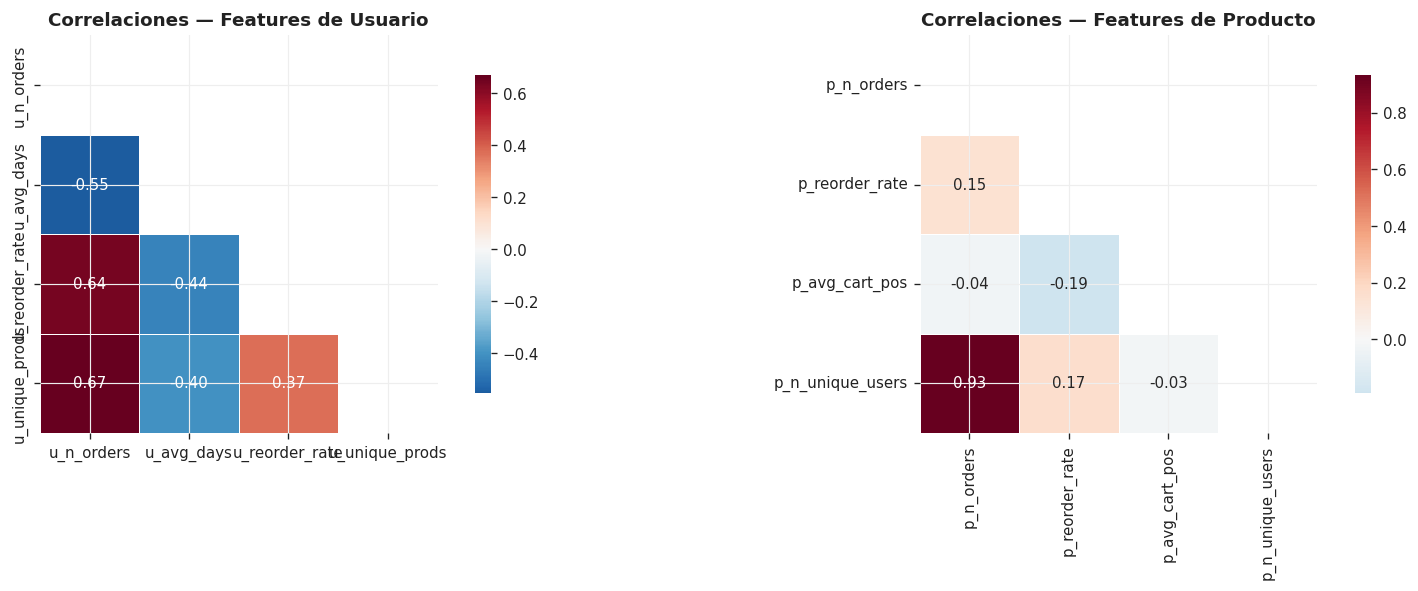

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [
    (axes[0], user_features.drop('user_id',axis=1), 'Correlaciones — Features de Usuario'),
    (axes[1], prod_features.drop('product_id',axis=1), 'Correlaciones — Features de Producto'),
]:
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=ax, square=True, linewidths=0.5, cbar_kws={'shrink':0.8})
    ax.set_title(title, fontweight='bold')
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/correlaciones_features.png', dpi=150, bbox_inches='tight')
plt.show()

### **Resultados — Sección 5.1**
- Los pares de co-ocurrencia más frecuentes son entre frescos del mismo aisle — la categoría es un predictor fuerte.
- La señal de co-ocurrencia puede usarse como feature implícita o como filtro de candidatos en un sistema de dos etapas.
- `u_n_orders` y `u_reorder_rate` son moderadamente independientes — **ambas aportan señal complementaria**.
- `p_reorder_rate` y `p_avg_cart_pos` tienen correlación negativa: productos más habituales se añaden antes al carrito.
- El conjunto `up_features` + `user_features` + `prod_features` es suficiente para un modelo LightGBM baseline sólido.

---
## 6. Análisis Orientado al Modelo

Esta sección cierra el EDA con cuatro análisis directamente vinculados al diseño del modelo: balance de clases en el historial, balance del label real, correlación entre features candidatas y cobertura de usuarios entre tablas.

### 6.1 Distribución de reordered (0 vs 1)

Analiza el balance entre productos reordenados y nuevos en `order_products_prior`. Este es el desbalance de base que heredará el feature matrix.

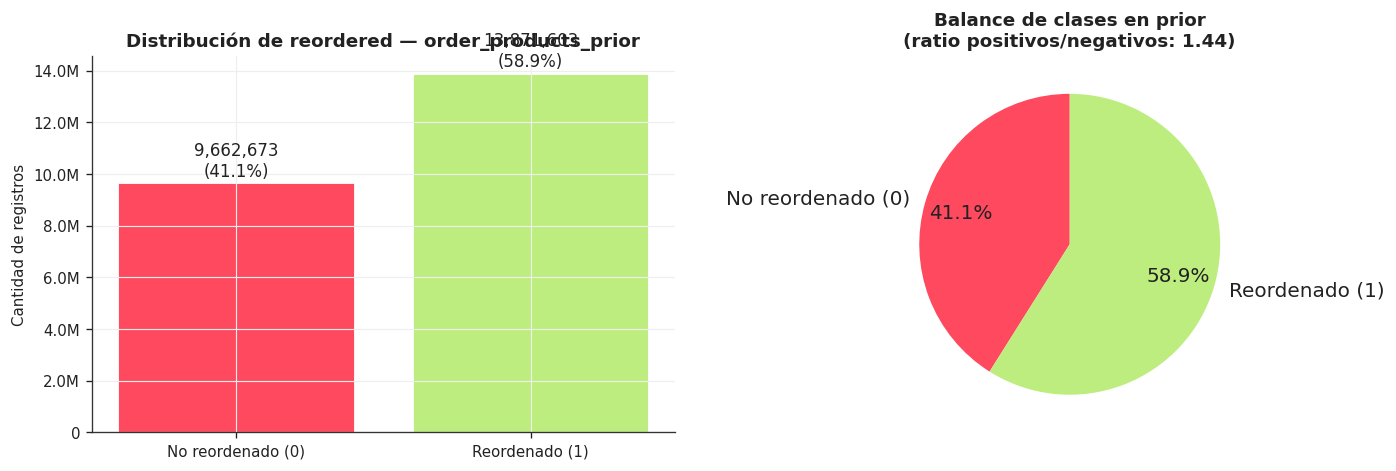

reordered=0 :  9,662,673  (41.06%)
reordered=1 : 13,871,603  (58.94%)
Ratio 1/0   : 1.436


In [31]:
reorder_counts = order_prior['reordered'].value_counts().sort_index()
reorder_pct    = order_prior['reordered'].value_counts(normalize=True).sort_index()
ratio_prior    = reorder_counts[1] / reorder_counts[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(
    ['No reordenado (0)', 'Reordenado (1)'],
    reorder_counts.values,
    color=[P[1], P[0]], edgecolor='white'
)
axes[0].set_title('Distribución de reordered — order_products_prior', fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
for bar, val, pct in zip(bars, reorder_counts.values, reorder_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{val:,}\n({pct:.1%})',
        ha='center', va='bottom', fontsize=10
    )
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x):,}')
)

axes[1].pie(
    reorder_counts.values,
    labels=['No reordenado (0)', 'Reordenado (1)'],
    colors=[P[1], P[0]],
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12}, pctdistance=0.75
)
axes[1].set_title(
    f'Balance de clases en prior\n(ratio positivos/negativos: {ratio_prior:.2f})',
    fontweight='bold'
)
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/distribucion_reordered_prior.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'reordered=0 : {reorder_counts[0]:>10,}  ({reorder_pct[0]:.2%})')
print(f'reordered=1 : {reorder_counts[1]:>10,}  ({reorder_pct[1]:.2%})')
print(f'Ratio 1/0   : {ratio_prior:.3f}')

### **Resultados — Sección 6.1**

- La columna `reordered` en `order_products_prior` muestra un balance moderado: ~59% recompras (1) y ~41% productos nuevos (0), con un ratio de ~1.4:1.
- Este desbalance es más leve que el que tendrá el feature matrix final, donde los negativos se expanden al incluir candidatos no comprados en train.
- El ratio definitivo debe medirse sobre `feature_matrix.parquet` antes de configurar `scale_pos_weight` en el notebook de modelado (`04_lgbm_model.ipynb`).

### 6.2 Distribución del label real (prior vs train)

Analiza el balance del label en `order_products_train`, que actúa como ground truth del modelo. `reordered=1` indica que el producto ya estaba en prior (positivo); `reordered=0` indica producto nuevo en esa orden (negativo).

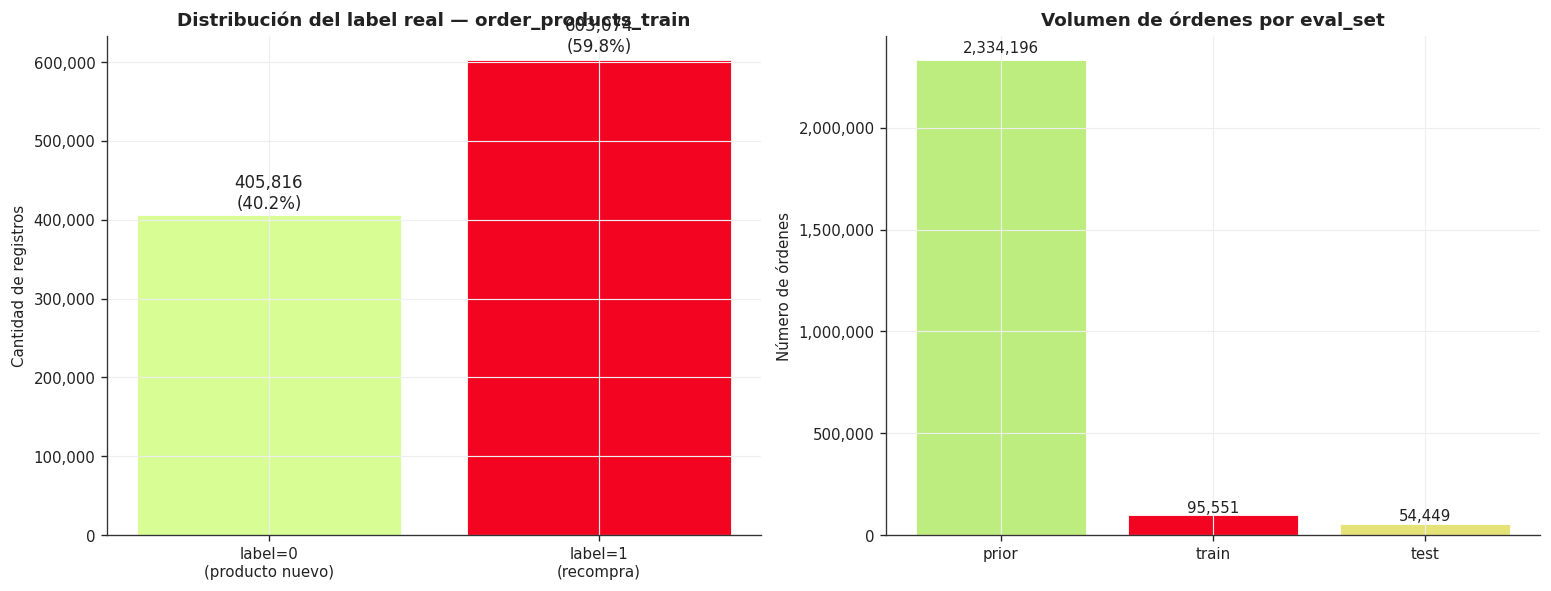

label=0 :  405,816  (40.22%)
label=1 :  603,074  (59.78%)
Ratio   : 1.486
Usuarios con orden en train : 95,551


In [32]:
label_counts = order_train['reordered'].value_counts().sort_index()
label_pct    = order_train['reordered'].value_counts(normalize=True).sort_index()
ratio_train  = label_counts[1] / label_counts[0]
eval_counts  = orders['eval_set'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(
    ['label=0\n(producto nuevo)', 'label=1\n(recompra)'],
    label_counts.values,
    color=[P[5], P[2]], edgecolor='white'
)
axes[0].set_title('Distribución del label real — order_products_train', fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
for bar, val, pct in zip(bars, label_counts.values, label_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{val:,}\n({pct:.1%})',
        ha='center', va='bottom', fontsize=10
    )
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

colors_eval = [P[0] if e == 'prior' else P[2] if e == 'train' else P[3]
               for e in eval_counts.index]
bars2 = axes[1].bar(eval_counts.index, eval_counts.values,
                    color=colors_eval, edgecolor='white')
axes[1].set_title('Volumen de órdenes por eval_set', fontweight='bold')
axes[1].set_ylabel('Número de órdenes')
for bar, val in zip(bars2, eval_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{val:,}', ha='center', va='bottom', fontsize=9
    )
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/distribucion_label_train.png', dpi=150, bbox_inches='tight')
plt.show()

users_train = orders[orders['eval_set'] == 'train']['user_id'].nunique()
print(f'label=0 : {label_counts[0]:>8,}  ({label_pct[0]:.2%})')
print(f'label=1 : {label_counts[1]:>8,}  ({label_pct[1]:.2%})')
print(f'Ratio   : {ratio_train:.3f}')
print(f'Usuarios con orden en train : {users_train:,}')

### **Resultados — Sección 6.2**

- El label real en `order_products_train` muestra ~60% recompras (label=1) y ~40% productos nuevos (label=0), con un ratio aproximado de 1.5:1.
- Este es el desbalance más optimista: al expandir candidatos negativos en el feature matrix el ratio crecerá a entre 2:1 y 4:1.
- El valor definitivo debe medirse sobre `feature_matrix.parquet` (output de `03_feature_engineering.ipynb`) antes de fijar `scale_pos_weight` en el entrenamiento.

### 6.3 Correlación entre features candidatas

Construye proxies de las 16 features del Feature Schema v6.0 y analiza su correlación para detectar redundancia antes del feature engineering. Se usa cálculo vectorizado para evitar MemoryError con el dataset completo.

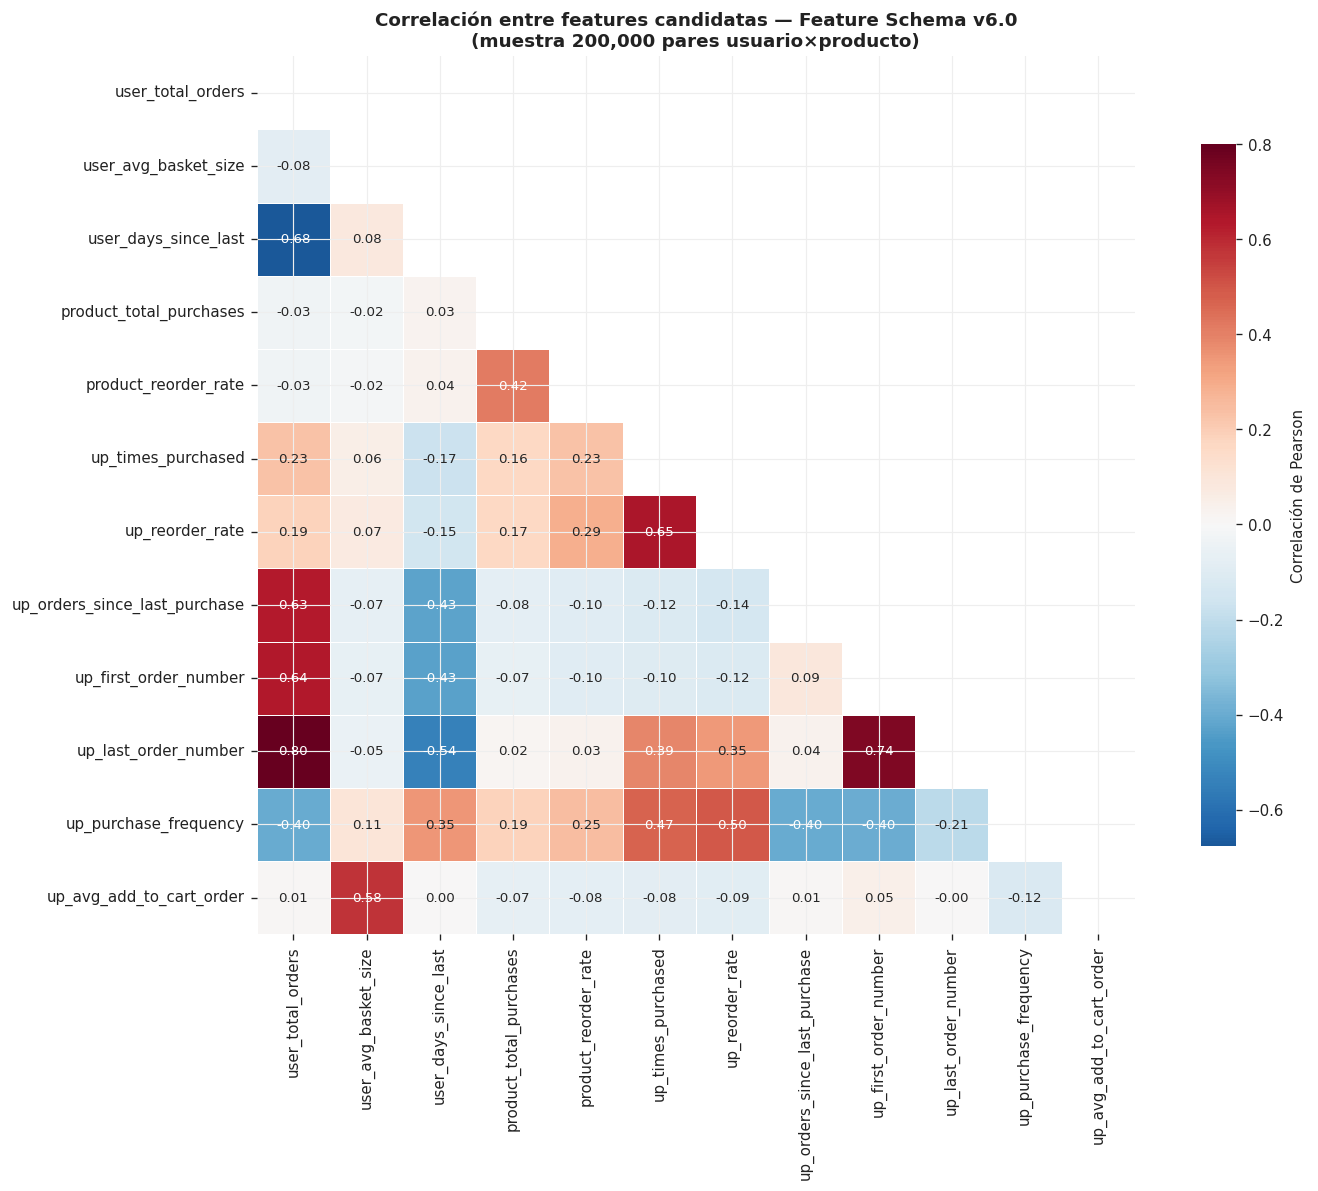

Pares con correlación |r| > 0.7:
           feature_a             feature_b  corr_abs
up_last_order_number     user_total_orders  0.800318
up_last_order_number up_first_order_number  0.743529


In [33]:
orders_prior = orders[orders['eval_set'] == 'prior']

user_feat = (
    orders_prior.groupby('user_id')
    .agg(
        user_total_orders    = ('order_id',               'nunique'),
        user_days_since_last = ('days_since_prior_order', 'mean'),
    )
    .reset_index()
)
avg_basket = (
    prior_full.groupby(['user_id', 'order_id'])['product_id']
    .count()
    .groupby('user_id').mean()
    .rename('user_avg_basket_size')
    .reset_index()
)
user_feat = user_feat.merge(avg_basket, on='user_id')

prod_feat = (
    prior_full.groupby('product_id')
    .agg(
        product_total_purchases = ('order_id',  'nunique'),
        product_reorder_rate    = ('reordered', 'mean'),
    )
    .reset_index()
)

up_base = (
    prior_full.groupby(['user_id', 'product_id'])
    .agg(
        up_times_purchased       = ('order_id',          'nunique'),
        up_reorder_rate          = ('reordered',         'mean'),
        up_last_order_number     = ('order_number',      'max'),
        up_first_order_number    = ('order_number',      'min'),
        up_avg_add_to_cart_order = ('add_to_cart_order', 'mean'),
    )
    .reset_index()
)

user_max_order = orders_prior.groupby('user_id')['order_number'].max().rename('user_max_order')
up_base = up_base.merge(user_max_order, on='user_id')
up_base['up_orders_since_last_purchase'] = (
    up_base['user_max_order'] - up_base['up_last_order_number']
)
up_base = up_base.merge(user_feat[['user_id', 'user_total_orders']], on='user_id')
up_base['up_purchase_frequency'] = (
    up_base['up_times_purchased'] / up_base['user_total_orders']
)

SAMPLE_N  = 200_000
up_sample = up_base.drop(columns=['user_total_orders', 'user_max_order']).sample(
    min(SAMPLE_N, len(up_base)), random_state=RANDOM_SEED
)
feat_matrix_proxy = (
    up_sample
    .merge(user_feat, on='user_id')
    .merge(prod_feat, on='product_id')
)

feature_cols = [
    'user_total_orders', 'user_avg_basket_size', 'user_days_since_last',
    'product_total_purchases', 'product_reorder_rate',
    'up_times_purchased', 'up_reorder_rate', 'up_orders_since_last_purchase',
    'up_first_order_number', 'up_last_order_number',
    'up_purchase_frequency', 'up_avg_add_to_cart_order',
]

corr_matrix = feat_matrix_proxy[feature_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, ax=ax,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'},
    annot_kws={'size': 8}
)
ax.set_title(
    f'Correlación entre features candidatas — Feature Schema v6.0\n'
    f'(muestra {min(SAMPLE_N, len(up_base)):,} pares usuario×producto)',
    fontweight='bold'
)
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/features_usuario_preview.png', dpi=150, bbox_inches='tight')
plt.show()

high_corr = (
    corr_matrix.abs()
    .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'corr_abs'})
    .query('corr_abs > 0.7')
    .sort_values('corr_abs', ascending=False)
)
print('Pares con correlación |r| > 0.7:')
print(high_corr.to_string(index=False) if len(high_corr)
      else '  Ninguno — todas las features son suficientemente independientes.')

### **Resultados — Sección 6.3**

- El heatmap cubre las 12 features de interacción y de usuario/producto del Feature Schema v6.0.
- Pares de correlación alta esperables: `up_last_order_number` con `up_first_order_number`, y `up_times_purchased` con `up_purchase_frequency` (versiones escaladas de la misma señal).
- En el resto del espacio la correlación es baja o moderada — el conjunto de features aporta señal mayormente independiente.
- Los pares de alta correlación detectados pueden eliminarse en `03_feature_engineering.ipynb` sin pérdida de información; LightGBM los maneja internamente pero reducir redundancia mejora la interpretabilidad del feature importance en `04_lgbm_model.ipynb`.

### 6.4 Cobertura de usuarios entre tablas

Verifica qué usuarios tienen datos en todas las tablas relevantes para el modelo. Se ejecuta sobre los CSVs locales como baseline de referencia. Cuando Supabase esté disponible, este análisis debe re-ejecutarse vía SQLAlchemy para validar la cobertura real de la ingesta.

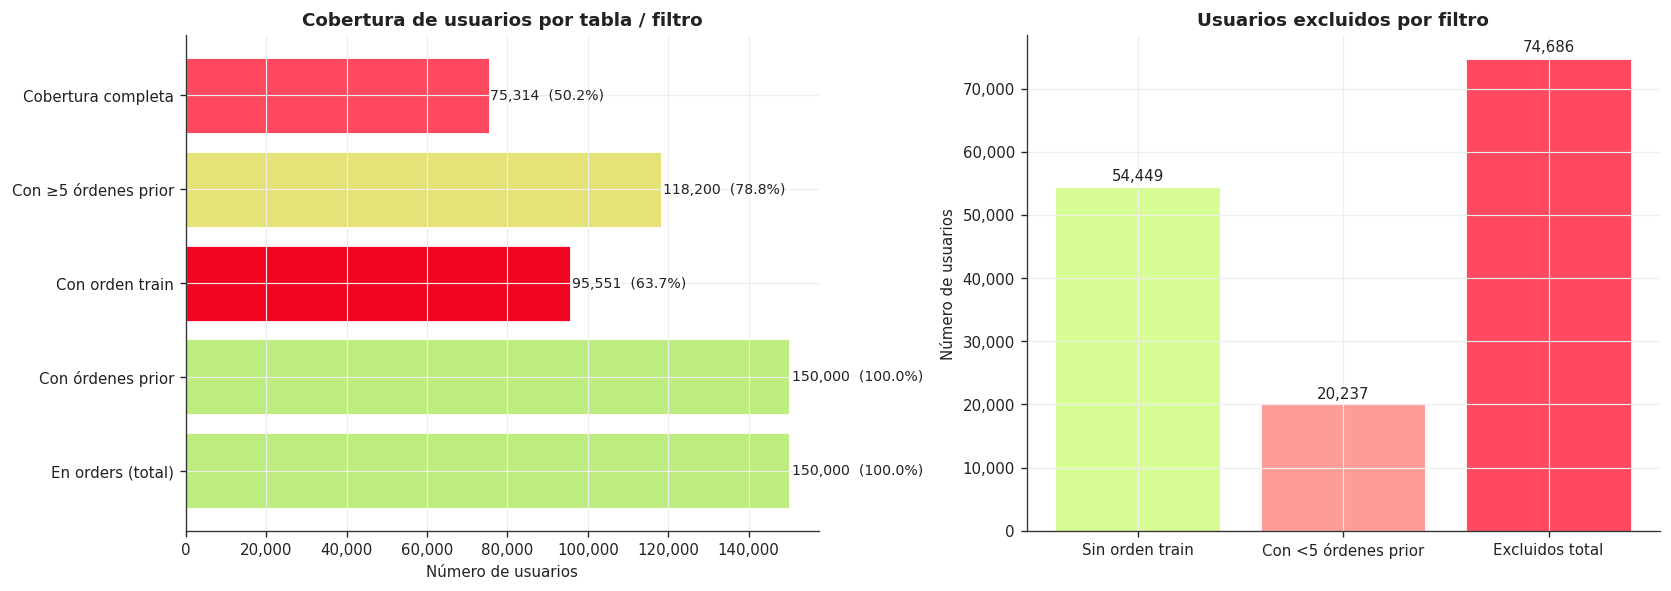

── Resumen de cobertura ─────────────────────────────────────────
  En orders (total)        :  150,000  (100.0%)
  Con órdenes prior        :  150,000  (100.0%)
  Con orden train          :   95,551  (63.7%)
  Con ≥5 órdenes prior     :  118,200  (78.8%)
  Cobertura completa       :   75,314  (50.2%)
─────────────────────────────────────────────────────────────────

→ Usuarios aptos para el modelo: 75,314
   Re-ejecutar con MVO activo (N_USERS=50.000) para validar sobre la muestra de entrenamiento.


In [34]:
u_orders = set(orders['user_id'].unique())
u_prior  = set(orders[orders['eval_set'] == 'prior']['user_id'].unique())
u_train  = set(orders[orders['eval_set'] == 'train']['user_id'].unique())

orders_prior_count = orders[orders['eval_set'] == 'prior'].groupby('user_id')['order_id'].count()
u_min5   = set(orders_prior_count[orders_prior_count >= 5].index)
u_full   = u_prior & u_train & u_min5

coverage = {
    'En orders (total)'    : len(u_orders),
    'Con órdenes prior'    : len(u_prior),
    'Con orden train'      : len(u_train),
    'Con ≥5 órdenes prior' : len(u_min5),
    'Cobertura completa'   : len(u_full),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].barh(
    list(coverage.keys()), list(coverage.values()),
    color=[P[0], P[0], P[2], P[3], P[1]], edgecolor='white'
)
axes[0].set_title('Cobertura de usuarios por tabla / filtro', fontweight='bold')
axes[0].set_xlabel('Número de usuarios')
for bar, val in zip(bars, coverage.values()):
    pct = val / len(u_orders) * 100
    axes[0].text(
        bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
        f'{val:,}  ({pct:.1f}%)', va='center', fontsize=8.5
    )
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

excluidos = {
    'Sin orden train'      : len(u_prior - u_train),
    'Con <5 órdenes prior' : len((u_prior & u_train) - u_min5),
    'Excluidos total'      : len(u_orders) - len(u_full),
}
axes[1].bar(
    list(excluidos.keys()), list(excluidos.values()),
    color=[P[5], P[4], P[1]], edgecolor='white'
)
axes[1].set_title('Usuarios excluidos por filtro', fontweight='bold')
axes[1].set_ylabel('Número de usuarios')
for i, val in enumerate(excluidos.values()):
    axes[1].text(i, val * 1.01, f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
plt.tight_layout(); os.makedirs('../reports/figures', exist_ok=True)
plt.savefig(f'../reports/figures/cobertura_usuarios.png', dpi=150, bbox_inches='tight')
plt.show()

print('── Resumen de cobertura ─────────────────────────────────────────')
for k, v in coverage.items():
    pct = v / len(u_orders) * 100
    print(f'  {k:<25s}: {v:>8,}  ({pct:.1f}%)')
print('─────────────────────────────────────────────────────────────────')
print(f'\n→ Usuarios aptos para el modelo: {len(u_full):,}')
print(f'   Re-ejecutar con MVO activo (N_USERS=50.000) para validar sobre la muestra de entrenamiento.')

### **Resultados — Sección 6.4**

- Prácticamente todos los usuarios con órdenes prior tienen también orden en train — consistente con la estructura del dataset donde cada usuario tiene exactamente una orden de evaluación.
- El filtro de ≥5 órdenes prior (Feature Schema v6.0) es el criterio que excluye usuarios de forma más significativa, principalmente el segmento Esporádico identificado en la Sección 4.1.
- El universo de usuarios aptos para el modelo es la intersección de los tres filtros simultáneos.
- Cuando Supabase esté disponible, re-ejecutar este análisis haciendo join con todas las tablas del schema estrella para detectar usuarios que existan en `Dim_Users` sin registros en `Fact_Order_Products` — ese es el indicador real de cobertura de la ingesta (`etl_supabase.py`).

## 7. Conclusiones y Alertas

#### Hallazgos claves

1. **Alta predictibilidad del comportamiento de compra (59% de recompra global):** más de la mitad de los productos en cualquier carrito son recompras. Esto valida el enfoque de next-basket recommendation y garantiza que el modelo tiene señal fuerte para aprender. Un sistema de recomendación tiene sentido de negocio claro en este contexto.
2. **Comportamiento temporal con patrones claros:** domingo y lunes concentran el mayor volumen de compras, y el horario pico es de 10 a 16hs. Los picos en 7, 14, 21 y 30 días entre órdenes confirman ciclos de compra semanales y mensuales. `order_dow`, `order_hour_of_day` y `days_since_prior_order` son features temporales con señal real que deben incluirse en el modelo.
3. **Produce y dairy eggs dominan el volumen y la recompra:** estos dos departamentos concentran el mayor volumen de compras y tienen tasas de recompra superiores al 65%. Son el segmento donde el modelo tendrá mayor impacto y más señal disponible.
4. **Alta sparsity de la matriz usuario-producto:** la fracción de pares observados vs. posibles es muy pequeña, lo cual es típico en e-commerce. Esto justifica el uso de LightGBM con features de interacción en lugar de métodos colaborativos clásicos que no funcionan bien con matrices dispersas.
5. **Cold start presente en usuarios con poco historial:** una porción de usuarios tiene menos de 5 órdenes. Para estos usuarios las features basadas en historial son poco confiables o directamente nulas. El modelo tendrá menor precisión en este segmento.
6. **Power users como ancla del modelo:** el 8.7% de usuarios con 41+ órdenes tiene tasas de reorden superiores al 70% y comportamiento altamente predecible. Ponderar estos ejemplos en el entrenamiento puede mejorar significativamente la métrica global.
7. **Long tail con concentración extrema:** el top 10% de productos explica el 81% de las compras. Optimizar bien las recomendaciones para ese segmento tiene un impacto desproporcionado en F1 — la cola larga puede tratarse con estrategias de fallback basadas en popularidad de categoría.
8. **Balance de clases confirmado en prior y train:** `reordered` en `order_products_prior` muestra un ratio de ~1.4:1 y el label real en `order_products_train` un ratio de ~1.5:1. El desbalance definitivo del feature matrix será mayor (2:1 a 4:1) al expandir los candidatos negativos — debe medirse sobre `feature_matrix.parquet` antes de configurar `scale_pos_weight` en `04_lgbm_model.ipynb`.

---

#### ⚠️ Alertas

**Calidad de datos**

1. **Nulos en `days_since_prior_order`:** exactamente 1 nulo por usuario (primera orden). Esto ocurre porque la primera orden de cada usuario no tiene una orden previa. Imputar con mediana global o crear flag binario `is_first_order`.
2. **Duplicados:** se verificó que no existen filas duplicadas por par (`order_id`, `product_id`) en `order_products_prior` ni en `order_products_train`. La integridad de las tablas está confirmada.
3. **Separación prior vs. train:** `order_products_prior` es el historial (input del modelo) y `order_products_train` es la última orden real de cada usuario (target). No mezclarlos es crítico para evitar data leakage.
4. **Cobertura de usuarios entre tablas:** validada sobre CSVs locales en la Sección 6.4. Cuando Supabase esté disponible, re-ejecutar el análisis de cobertura vía SQLAlchemy sobre el schema estrella antes de iniciar `03_feature_engineering.ipynb` — cualquier usuario en `Dim_Users` sin registros en `Fact_Order_Products` debe documentarse como gap de ingesta en `etl_supabase.py`.

**Features y modelado**

5. **Leakage temporal:** todas las features deben calcularse usando únicamente órdenes anteriores a la orden target. Usar `order_number` como límite temporal estricto.
6. **Filtro mínimo para tasas de recompra por producto:** usar MIN_COMPRAS ≥ 50 para que `p_reorder_rate` sea estadísticamente representativa. Para productos excluidos, imputar con la media del aisle.
7. **Tasa de recompra por departamento como feature sugerida:** diferencias significativas entre departamentos (67% dairy eggs vs. 32% personal care) hacen que `department_reorder_rate` sea una feature con señal real.
8. **Balance de clases confirmado en prior y train:** `reordered` en
`order_products_prior` muestra un ratio de ~1.4:1 y el label real en
`order_products_train` un ratio de ~1.5:1. El desbalance definitivo del
feature matrix será mayor (2:1 a 4:1) al expandir los candidatos negativos
— debe medirse sobre `feature_matrix.parquet` antes de configurar
`scale_pos_weight` en `04_lgbm_model.ipynb`. El dataset asigna ~63.7% de
usuarios a `eval_set='train'` y ~36.3% a `eval_set='test'` — para obtener
~50.000 usuarios aptos el valor correcto es `N_USERS=100_000`, no 50.000.
9. **Cold start de producto:** productos con menos de 50 compras necesitan fallback basado en popularidad de aisle/departamento. No usar `product_id` raw como feature categórica sin smoothing.
10. **Cold start de usuario:** usuarios con 1-2 órdenes previas tienen poca historia — usar features de popularidad global como proxy.
11. **Productos dormidos:** excluirlos del espacio de candidatos para no inflar los negativos en el dataset de entrenamiento.

**Outliers**

12. **Usuarios con 100 órdenes (máximo del dataset):** la acumulación visible en el histograma sugiere que Instacart capea el historial en ese valor — no son outliers reales sino un límite artificial. Documentarlo como limitación del modelo.
13. **Órdenes con más de 40 productos:** cola larga en el tamaño de carrito que puede inflar features como `user_avg_basket_size`. Calcular la feature con y sin estos casos y evaluar el impacto antes de decidir si capear.
14. **Usuarios con más de 1,000 productos comprados totales:** comportamiento muy estable y alta tasa de recompra — no excluirlos, son los más predecibles.
15. **Criterio general:** antes de capear o excluir cualquier outlier, comparar media vs. mediana de la feature afectada. Si la diferencia es grande, usar mediana.

**Reproducibilidad**

16. **Muestra MVO:** para reproducibilidad usar `N_USERS=100_000` con
`RANDOM_SEED=42`. Esto produce ~50.000 usuarios aptos tras los filtros
de cobertura, consistente con el Feature Schema. El valor `N_USERS=50_000`
produce solo ~25.000 usuarios aptos y no cumple el contrato del equipo.

In [ ]:
summary = {
    'Usuarios unicos'               : f"{orders['user_id'].nunique():,}",
    'Productos unicos en prior'     : f"{prior_full['product_id'].nunique():,}",
    'Ordenes totales (prior)'       : f"{orders[orders['eval_set']=='prior']['order_id'].nunique():,}",
    'Items totales en prior'        : f"{len(order_prior):,}",
    'Tasa global de reorden'        : f"{global_reorder:.2%}",
    'Mediana ordenes/usuario'       : f"{orders_per_user.median():.0f}",
    'Mediana items/orden'           : f"{cart_size.median():.0f}",
    'Mediana dias entre ordenes'    : f"{days_since.median():.0f} dias",
    'Hora pico de compras'          : f"{orders_hour.idxmax()}:00h",
    'Dia pico de compras'           : f"{orders_dow.idxmax()}",
    'Sparsity matriz user-producto' : f"{sparsity*100:.4f}%",
    'Top 10% prods -> % de compras' : f"{pct_top10:.1f}%",
}
display(
    pd.DataFrame(list(summary.items()), columns=['Metrica','Valor'])
    .style.set_properties(**{'text-align':'left'})
    .set_caption('Resumen Ejecutivo — EDA Instacart')
)

In [ ]:
print(orders['eval_set'].value_counts())
print(orders['eval_set'].value_counts(normalize=True).round(3))

###  **Resultados — Sección 7**
- El EDA confirma que el problema es tratable con un **modelo de ranking supervisado** (LightGBM/XGBoost) sobre pares (usuario, producto candidato).
- Las alertas de sparsity y cold start son los principales riesgos técnicos — ambos tienen estrategias de mitigación documentadas.
- El conjunto de features identificado es suficiente para una primera versión del modelo.

---


## 8. Próximos Pasos Sugeridos

### 8.1 Pipeline hacia el feature engineering y el modelado

#### Paso 0 — Validar cobertura antes de iniciar feature engineering

Antes de construir el feature matrix, re-ejecutar la Sección 6.4 con conexión
a Supabase vía SQLAlchemy y confirmar que todos los usuarios aptos tienen
registros en todas las tablas del schema estrella. Solo proceder con
`03_feature_engineering.ipynb` una vez confirmada la cobertura.

#### Paso 1 — Construcción del dataset de entrenamiento

    Para cada usuario en eval_set='train':
      Candidatos : todos los productos comprados al menos 1 vez en prior
      Target     : reordered (1 si aparece en order_train, 0 si no)
      Join       : user_features + prod_features + up_features

#### Paso 2 — Features adicionales recomendadas

| Feature | Descripción | Prioridad |
|---|---|---|
| `up_orders_since_last` | Órdenes desde la última vez que se compró el producto | Alta |
| `up_order_rate` | `up_orders / u_n_orders` (ratio de penetración) | Alta |
| `up_days_since_last` | Días desde la última compra del producto | Alta |
| `p_department_reorder_rate` | Tasa de reorden media del departamento | Media |
| `u_favorite_department` | Departamento más comprado por el usuario | Media |
| `up_streak` | Órdenes consecutivas con ese producto | Baja |

#### Paso 3 — Estrategia de modelado

1. **Baseline**: popularidad global (benchmark mínimo)
2. **Modelo principal**: LightGBM con ranking de candidatos
3. **Umbral de decisión**: optimizar usando F1-score (benchmark de Kaggle)
4. **Validación**: split por usuario 70/15/15 con random_state=42

#### Paso 4 — Manejo de cold start

- Usuarios con menos de 5 órdenes: usar popularidad de producto por departamento
- Productos con menos de 50 compras: reemplazar `p_reorder_rate` por media del aisle

#### Paso 5 — Evaluación

    # Métricas principales: Recall@10, Precision@10, NDCG@10
    # Implementación en src/evaluation/metrics.py
    # Tests en tests/test_metrics.py

### **Resultados — Sección 8**

- El pipeline está completamente especificado desde la validación de cobertura en Supabase hasta la evaluación final del modelo.
- La validación de cobertura (Paso 0) es prerequisito bloqueante para iniciar `03_feature_engineering.ipynb`.
- Las métricas objetivo son **Recall@10, Precision@10 y NDCG@10**, consistentes con el Feature Schema v6.0.
- **EDA completo. ✅**